# Antibiotic heteroresistance generated by plasmid copy-number variability
## Supplementary figure 6

### Fluorescense - Plasmid copy number correlation

## System preparation


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde
import scipy.stats as stats
import random


### Mounting Gdrive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### File paths

In [ ]:
rootDir="/content/drive/MyDrive/SYNC_Projects/"
rootDir=rootDir+"pBGT/ms/"

workingDir=rootDir+"code/Supplementary/"
data_path=rootDir+"data/sFig6-G54U_G55U/"
qpcr_raw_data_path=data_path+"qPCR/"
amnis_raw_data_path=data_path+"AMNIS/"
synergy_raw_data_path=data_path+"Synergy/"
sfig_path=rootDir+"figures/SuppFigures/"
out_fig_name=sfig_path+"sFig_G54U_G55U.pdf"
out_fig_name

'/content/drive/MyDrive/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig_G54U_G55U.pdf'

## qPCRs

### Setup primers efficiency


In [ ]:

eff_dxs=1
eff_tem=1

eff_dxs1=1.3549  
eff_dxs2=1.2069 

eff_dxs1=1.1673  #using 8-fold
eff_dxs=1.0439  #using 8-fold and discarting more diluted reaction

eff_tem=1.2317
eff_tem=1.0647  #using 8-fold

#eff_dxs=.98
#eff_tem=.97  #using 8-fold

### G54U

#### Amplification Overview

In [ ]:

G54_file_ampli=qpcr_raw_data_path+"G54U/G54U_4repsbio_3repstech -  Quantification Amplification Results_SYBR.csv"
G54_df_ampli=pd.read_csv(G54_file_ampli)
G54_df_ampli.head()

,Unnamed: 0,Cycle,A1,A2,A3,A4,A5,A6,A7,A8,...,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
0,NaN,1,-7.987968,-21.583157,-12.598373,-8.523945,-2.137198,-6.500291,-18.669900,0.287648,...,-2.069761,22.859104,28.966603,29.382650,-1.898650,6.142356,-1.715186,-4.479003,-4.042176,-14.468794
1,NaN,2,1.328584,-6.885942,-5.209806,0.520445,-0.548097,-1.038352,-8.036682,0.879188,...,4.408350,37.316389,46.892750,44.102569,2.414817,14.884676,9.218385,5.743156,2.938378,-0.550169
2,NaN,3,2.377908,0.516546,0.326181,0.338275,1.778426,8.312857,1.584531,4.925446,...,5.945194,47.317682,54.633735,51.436070,3.981482,7.870442,3.381447,3.176984,0.375846,2.341015
3,NaN,4,4.399001,-1.819625,0.394415,3.231624,2.093131,0.303423,-2.120778,0.455742,...,4.156808,57.686467,63.295767,53.736370,2.973265,5.348779,6.324324,-0.860375,-0.806214,3.444485
4,NaN,5,2.229174,3.230621,4.444828,2.602221,3.643215,0.047898,1.310621,-1.253017,...,2.960018,66.847917,82.141741,71.190166,4.224136,1.882415,3.129329,7.022467,5.122343,-0.063617


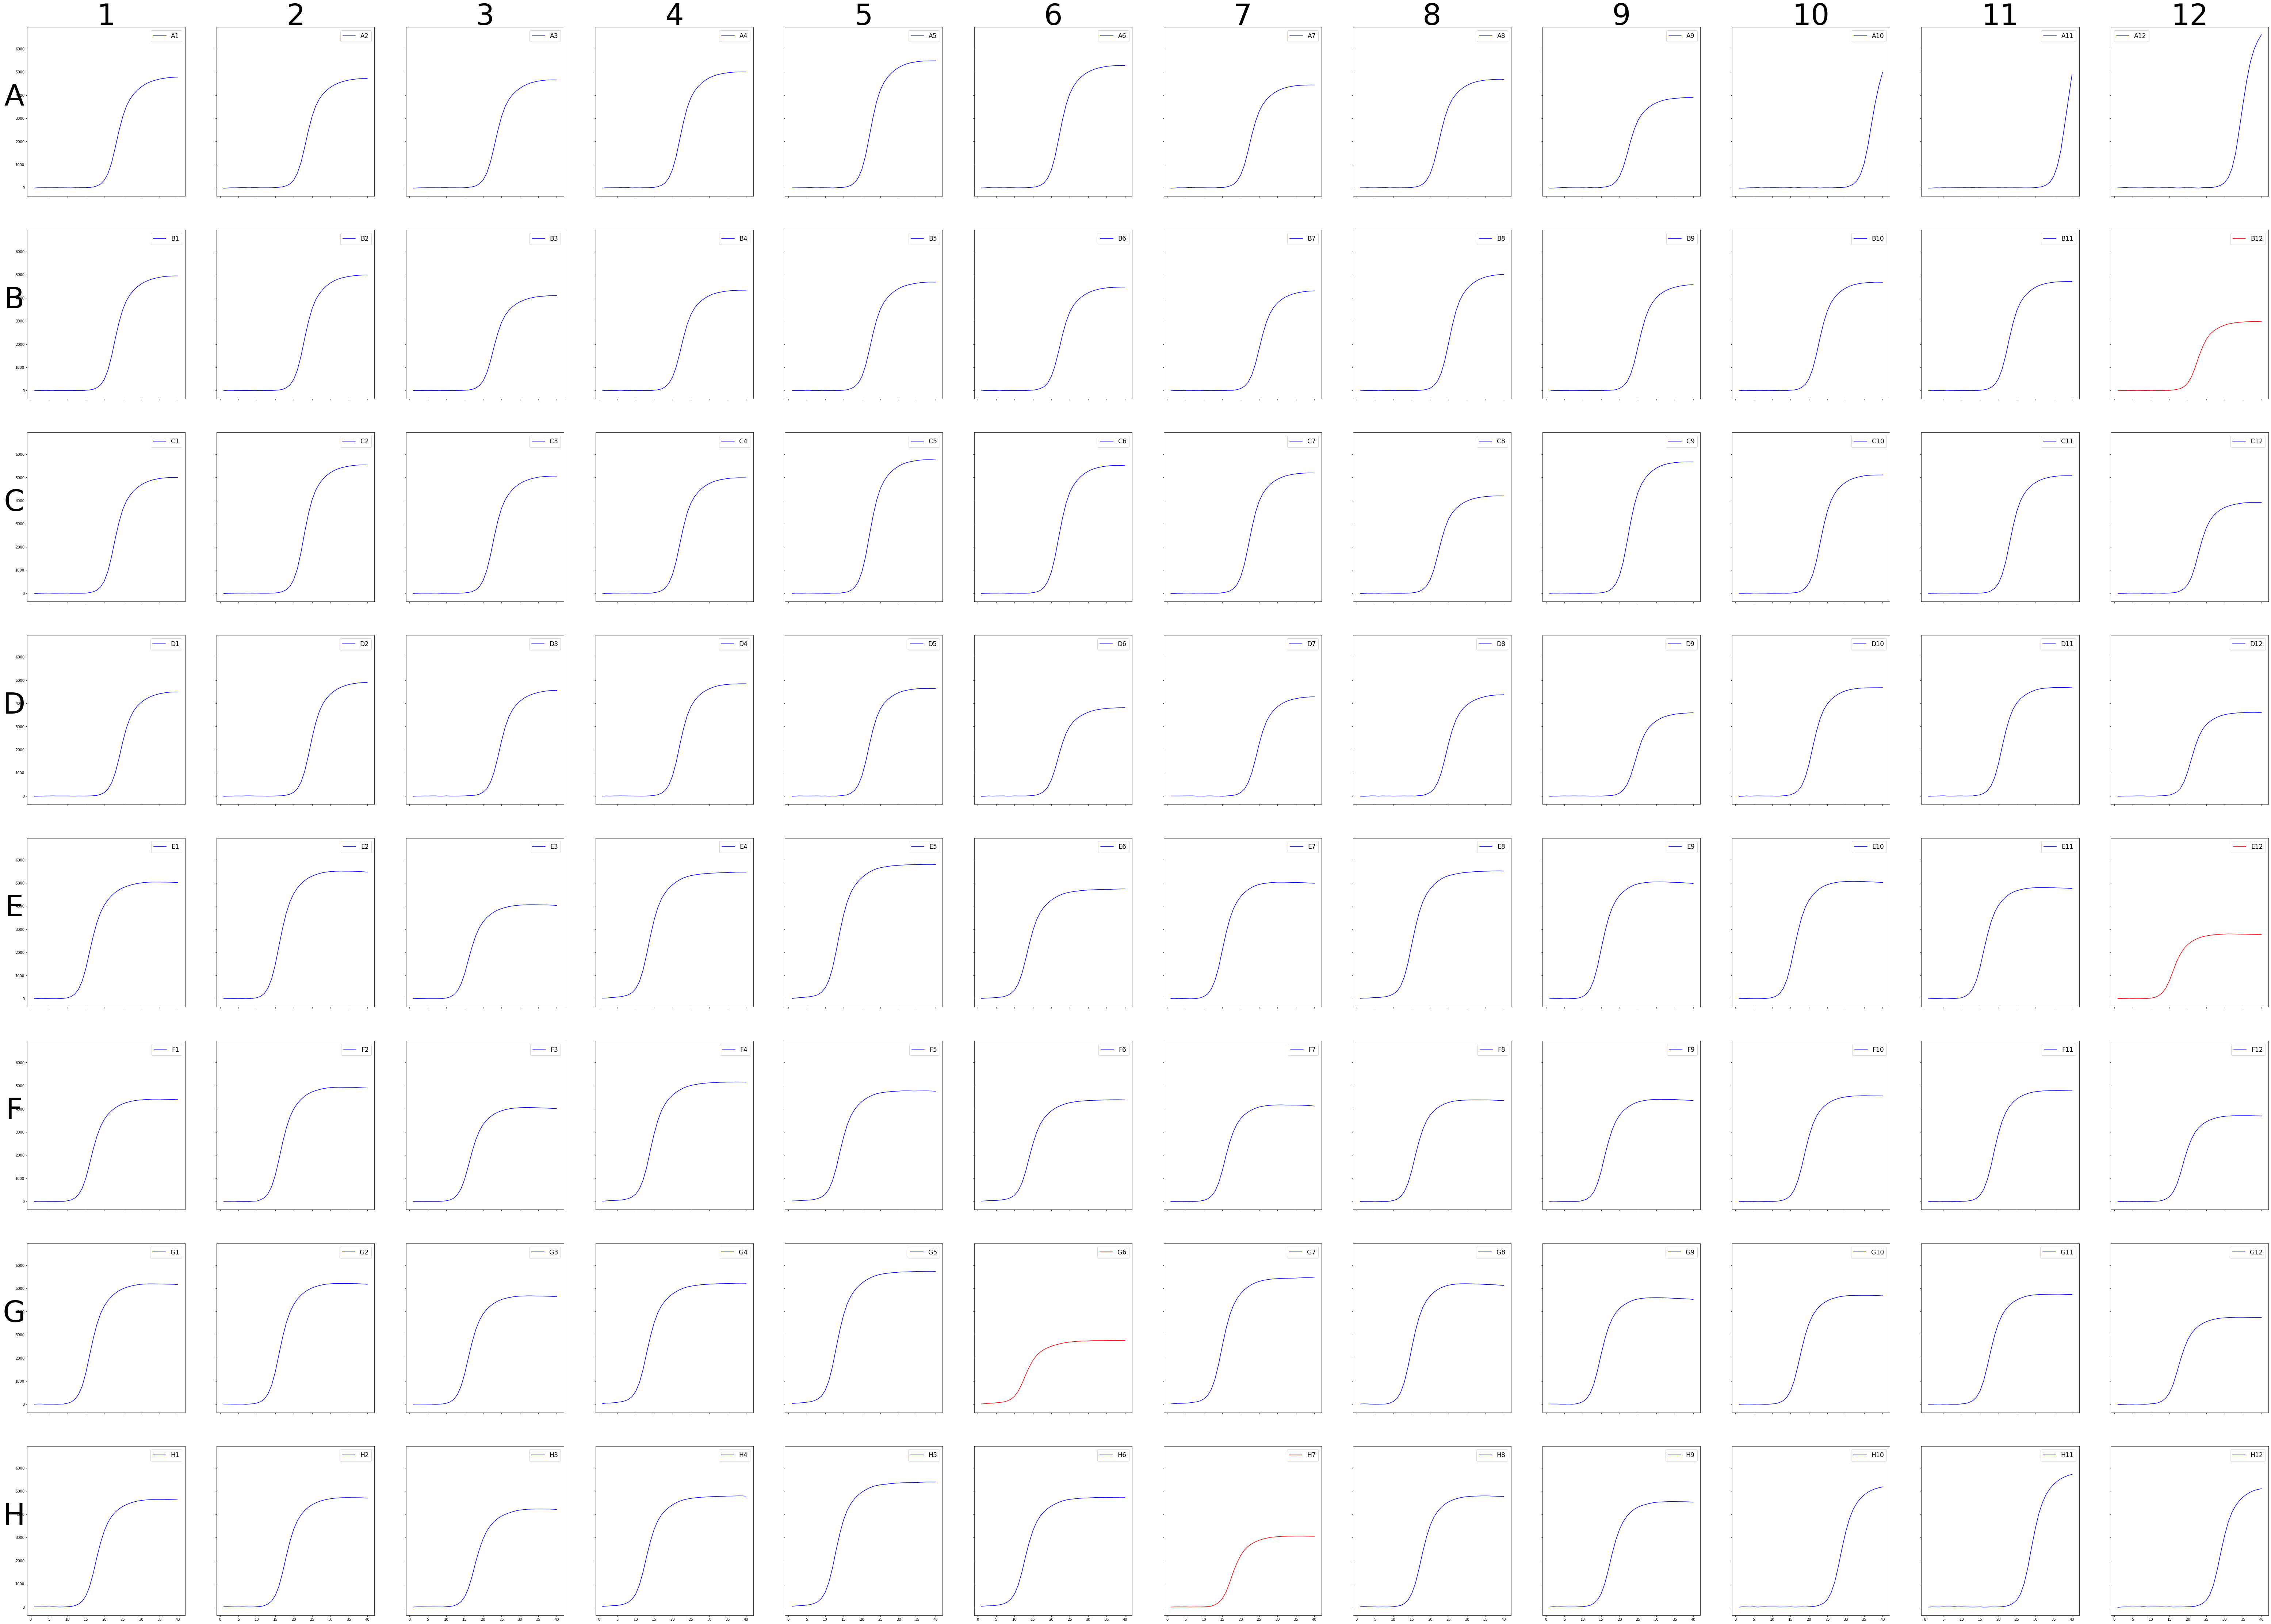

In [ ]:
cols=[x for x in np.arange(1,13)]
rows="A B C D E F G H"
rows=rows.split()
fig,axs=plt.subplots(len(rows),len(cols),sharex=True,sharey=True,figsize=(110,80))
time=G54_df_ampli["Cycle"]
G54_exclude_wells=[]
for ri,row in enumerate(rows):
    for ci,col in enumerate(cols):
        well=row+str(col)
        vals=list(G54_df_ampli[well])
        color='b'
        if(vals[-1]<3100):
            color='r'
            G54_exclude_wells.append(well)
        axs[ri,ci].plot(time,vals,c=color,label=well)
        axs[ri,ci].legend(fontsize="xx-large")

for ax, col in zip(axs[0], cols):
    ax.set_title(col,size=80)

for ax, row in zip(axs[:,0], rows):
    ax.set_ylabel(row, rotation=0, size=80)
    
plt.show()

#### Select wells to exclude from analysis

In [ ]:
G54_ex_wells=[]
print(G54_exclude_wells)
for x in G54_exclude_wells:
    st=[y for y in x]
    #print(st)
    if(len(x)<3):
        st=st[0]+"0"+st[1]
    else:
        st=st[0]+st[1]+st[2]
    G54_ex_wells.append(st)
G54_ex_wells


['B12', 'E12', 'G6', 'H7']


['B12', 'E12', 'G06', 'H07']

#### Read Ct file

In [ ]:
G54_file=qpcr_raw_data_path+"G54U/G54U_4repsbio_3repstech -  Quantification Cq Results.csv"
G54_df_all=pd.read_csv(G54_file)
G54_df_all.head()


,Unnamed: 0,Well,Fluor,Target,Content,Sample,Biological Set Name,Cq,Cq Mean,Cq Std. Dev,Starting Quantity (SQ),Log Starting Quantity,SQ Mean,SQ Std. Dev,Set Point,Well Note
0,NaN,A01,SYBR,dxs,Std,lb-1,rep1,21.466125,21.466125,0,1000000.0,6.0,1000000.0,0,60,NaN
1,NaN,A02,SYBR,dxs,Std,lb-1,rep1,21.432083,21.432083,0,1000000.0,6.0,1000000.0,0,60,NaN
2,NaN,A03,SYBR,dxs,Std,lb-1,rep1,21.413878,21.413878,0,1000000.0,6.0,1000000.0,0,60,NaN
3,NaN,A04,SYBR,dxs,Std,amp-2,rep1,20.073895,20.073895,0,1000000.0,6.0,1000000.0,0,60,NaN
4,NaN,A05,SYBR,dxs,Std,amp-2,rep1,20.046059,20.046059,0,1000000.0,6.0,1000000.0,0,60,NaN


In [ ]:
primers=["dxs","tem"]
G54_day1_repsT=["01","02","03"]
G54_day2_repsT=["04","05","06"]
G54_day3_repsT=["07","08","09"]
G54_days=[G54_day1_repsT,G54_day2_repsT,G54_day3_repsT]
G54_repsB_dxs=["A","B","C","D"]
G54_repsB_tem=["E","F","G","H"]

G54_control_repsT=["10","11","12"]
G54_control_days_dxs=["B","C","D"] 
G54_control_days_tem=["E","F","G"] 



xxxxx C06 G06
xxxxx D07 H07


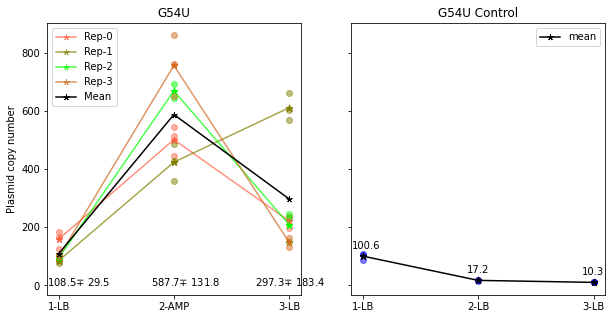

In [ ]:

fig,ax=plt.subplots(1,2,figsize=(10,5),sharey=True)
col_mean=[]
for row in range(0,len(G54_control_days_dxs)):
    row_mean_d=[]
    row_mean_t=[]
    row_mean_cn=[]
    for ci,col in enumerate(G54_control_repsT):
        well_d=G54_control_days_dxs[row]+str(col)
        well_t=G54_control_days_tem[row]+str(col)
        ct_d=list(G54_df_all[G54_df_all["Well"]==well_d]["Cq"])[0]
        ct_t=list(G54_df_all[G54_df_all["Well"]==well_t]["Cq"])[0]
        cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
        if(np.isnan(cn_eff)):
            continue
        row_mean_d.append(ct_d)
        row_mean_t.append(ct_t)
        row_mean_cn.append(cn_eff)
        ax[1].scatter(row+1,cn_eff,c='b',alpha=.5)
    mean_d=np.mean(row_mean_d)
    mean_t=np.mean(row_mean_t)
    mean_cn=np.mean(row_mean_cn)
    col_mean.append(mean_cn)
    ax[1].scatter(row+1,mean_cn,c='k',marker=(5, 2))
    
ax[1].plot([1,2,3],col_mean,c='k',marker=(5, 2),label="mean")
for x in range(1,4):
    m=round(col_mean[x-1],1)
    
    ax[1].text(x-.1,m+25,'%s'%(m))


clrs=["tomato", "olive","lime","chocolate"]

normv=1

all_means=[]
for ri in range(0,len(G54_repsB_dxs)):
    bio_mean_cn=[]
    for di,day in enumerate(G54_days):
        tech_mean_d=[]
        tech_mean_t=[]
        tech_mean_cn=[]
        for ci,col in enumerate(day):
            well_d=G54_repsB_dxs[ri]+col
            well_t=G54_repsB_tem[ri]+col
            ct_d=list(G54_df_all[G54_df_all["Well"]==well_d]["Cq"])[0]
            ct_t=list(G54_df_all[G54_df_all["Well"]==well_t]["Cq"])[0]
            cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
            #normv=col_mean[0]
            cn_eff=cn_eff/normv
            
            if(np.isnan(cn_eff)):
                print("xxx",well_d, well_t)
                continue
            if(well_d in G54_ex_wells or well_t in G54_ex_wells):
                print("xxxxx",well_d, well_t)
                continue
            tech_mean_d.append(ct_d)
            tech_mean_t.append(ct_t)
            tech_mean_cn.append(cn_eff)
            #print(well_d,round(ct_d,1),round(ct_t,1),"->",cn_eff,end="\t")
            ax[0].scatter(di+1,cn_eff,c=clrs[ri],alpha=.5)
        mean_d=np.mean(tech_mean_d)
        mean_t=np.mean(tech_mean_t)
    
        mean_cn=np.mean(tech_mean_cn)
        ax[0].scatter(di+1,mean_cn,c=clrs[ri],marker=(5, 2))
        bio_mean_cn.append(mean_cn)
        
    all_means.append(bio_mean_cn)
    ax[0].plot([1,2,3],bio_mean_cn,c=clrs[ri],alpha=.7,marker=(5, 2),label="Rep-%s"%ri)
y1=[x[0] for x in all_means]    
y2=[x[1] for x in all_means]    
y3=[x[2] for x in all_means]
ys=[y1,y2,y3]
means=[np.mean(y) for y in ys]
stds=[np.std(y) for y in ys]

ax[0].plot([1,2,3],means,c='k',marker=(5, 2),label="Mean")
xs=["1-LB","2-AMP","3-LB"]
ax[0].legend()
ax[0].set_xticks([1,2,3])
ax[0].set_xticklabels(xs)
ax[0].set_ylabel("Plasmid copy number")
ax[0].set_title("G54U")
for x in range(1,4):
    m=round(means[x-1],1)
    s=round(stds[x-1],1)
    ax[0].text(x-(.1*x),0,r'%s$\mp$ %s'%(m,s))

xs=["1-LB","2-LB","3-LB"]
ax[1].legend()
ax[1].set_xticks([1,2,3])
ax[1].set_xticklabels(xs)
ax[1].set_title("G54U Control")
#ax[1].set_yscale("log")
plt.show()



### G55U

#### Amplification Overview

In [ ]:
G55_file_ampli=qpcr_raw_data_path+"G55U/G55U_4repsbio_3repstech -  Quantification Amplification Results_SYBR.csv"
G55_df_ampli=pd.read_csv(G55_file_ampli)
G55_df_ampli.head()

,Unnamed: 0,Cycle,A1,A2,A3,A4,A5,A6,A7,A8,...,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
0,NaN,1,-5.974423,3.887024,-0.809522,2.004167,0.009848,-15.941656,6.122522,0.100395,...,12.103047,9.166837,19.688870,8.244609,27.417988,12.208384,1.969707,-4.891869,-12.069407,-14.306238
1,NaN,2,6.836864,2.899426,5.776762,7.272473,4.440015,-6.640786,10.849384,11.538617,...,13.177826,29.365455,35.564633,30.967392,22.750256,16.864332,10.887490,8.118104,-6.932390,-6.283152
2,NaN,3,0.039892,1.608720,3.546169,3.590779,6.596491,1.359380,6.205819,8.230602,...,8.406397,40.181957,40.401040,38.157015,14.153770,4.303040,10.579706,13.086438,-3.542605,1.110292
3,NaN,4,1.417979,6.812412,3.154990,7.165312,8.083372,2.487218,6.858828,3.676014,...,5.711175,50.723424,47.629234,54.493729,7.555711,10.589437,5.829614,15.295560,2.568626,3.405673
4,NaN,5,4.147984,5.548033,2.763558,2.471095,0.172926,5.282717,2.477156,3.732469,...,-1.808043,58.173939,56.355356,59.434233,2.992591,2.917698,7.979145,19.119450,4.853978,6.973980


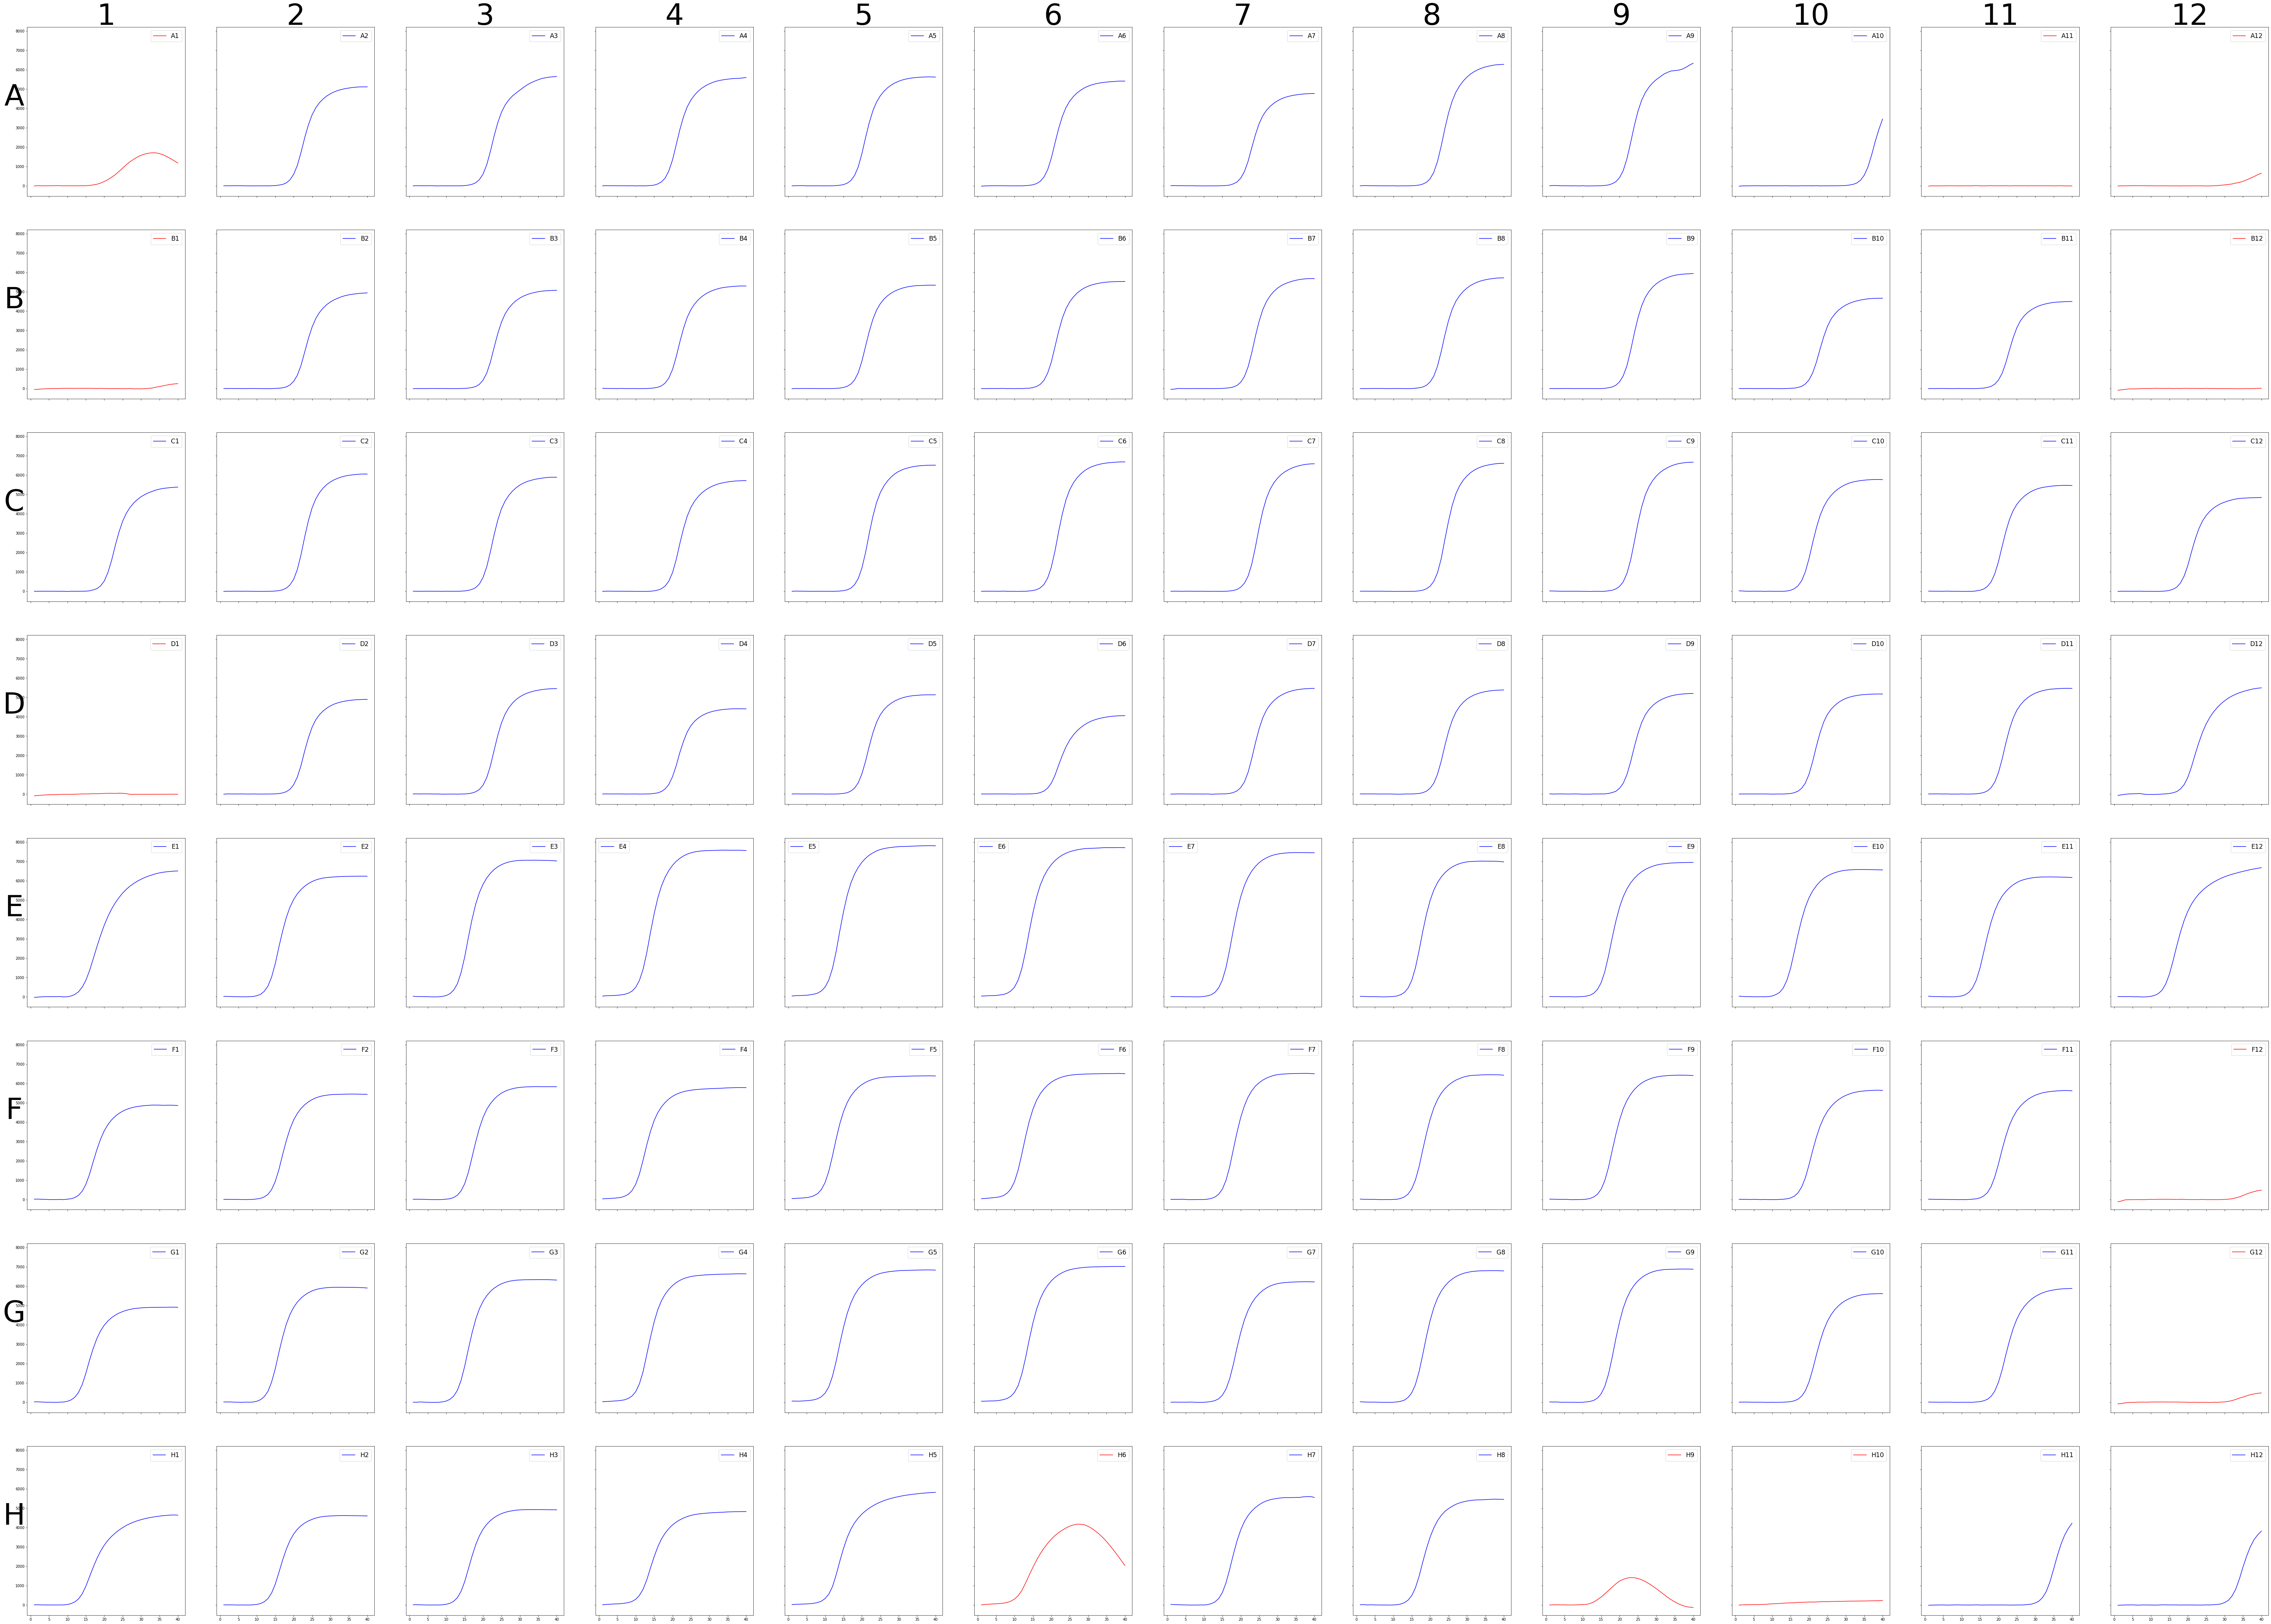

In [ ]:
cols=[x for x in np.arange(1,13)]
rows="A B C D E F G H"
rows=rows.split()
fig,axs=plt.subplots(len(rows),len(cols),sharex=True,sharey=True,figsize=(110,80))
time=G55_df_ampli["Cycle"]
G55_exclude_wells=[]
for ri,row in enumerate(rows):
    for ci,col in enumerate(cols):
        well=row+str(col)
        vals=list(G55_df_ampli[well])
        color='b'
        if(vals[-1]<3100):
            color='r'
            G55_exclude_wells.append(well)
        axs[ri,ci].plot(time,vals,c=color,label=well)
        axs[ri,ci].legend(fontsize="xx-large")

for ax, col in zip(axs[0], cols):
    ax.set_title(col,size=80)

for ax, row in zip(axs[:,0], rows):
    ax.set_ylabel(row, rotation=0, size=80)
    
plt.show()

#### Select wells to exclude from analysis

In [ ]:
G55_ex_wells=[]
print(G55_exclude_wells)
for x in G55_exclude_wells:
    st=[y for y in x]
    #print(st)
    if(len(x)<3):
        st=st[0]+"0"+st[1]
    else:
        st=st[0]+st[1]+st[2]
    G55_ex_wells.append(st)
G55_ex_wells


['A1', 'A11', 'A12', 'B1', 'B12', 'D1', 'F12', 'G12', 'H6', 'H9', 'H10']


['A01', 'A11', 'A12', 'B01', 'B12', 'D01', 'F12', 'G12', 'H06', 'H09', 'H10']

#### Read Ct file

In [ ]:
G55_file=qpcr_raw_data_path+"G55U/G55U_4repsbio_3repstech -  Quantification Cq Results.csv"
G55_df_all=pd.read_csv(G55_file)
G55_df_all.head()


,Unnamed: 0,Well,Fluor,Target,Content,Sample,Biological Set Name,Cq,Cq Mean,Cq Std. Dev,Starting Quantity (SQ),Log Starting Quantity,SQ Mean,SQ Std. Dev,Set Point,Well Note
0,NaN,A01,SYBR,dxs,Std,lb-1,rep1,25.087018,25.087018,0,1000000.0,6.0,1000000.0,0,60,NaN
1,NaN,A02,SYBR,dxs,Std,lb-1,rep1,20.725992,20.725992,0,1000000.0,6.0,1000000.0,0,60,NaN
2,NaN,A03,SYBR,dxs,Std,lb-1,rep1,20.664188,20.664188,0,1000000.0,6.0,1000000.0,0,60,NaN
3,NaN,A04,SYBR,dxs,Std,amp-2,rep1,19.287279,19.287279,0,1000000.0,6.0,1000000.0,0,60,NaN
4,NaN,A05,SYBR,dxs,Std,amp-2,rep1,18.890160,18.890160,0,1000000.0,6.0,1000000.0,0,60,NaN


In [ ]:
primers=["dxs","tem"]
G55_day1_repsT=["01","02","03"]
G55_day2_repsT=["04","05","06"]
G55_day3_repsT=["07","08","09"]
G55_days=[G55_day1_repsT,G55_day2_repsT,G55_day3_repsT]
G55_repsB_dxs=["A","B","C","D"]
G55_repsB_tem=["E","F","G","H"]

G55_control_repsT=["10","11","12"]
G55_control_days_dxs=["B","C","D"] 
G55_control_days_tem=["E","F","G"] 



xxxxx A01 E01
xxx B01 F01
xxx D01 H01
xxxxx D06 H06
xxxxx D09 H09


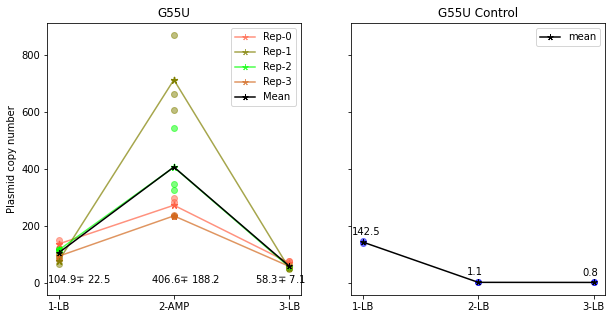

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(10,5),sharey=True)
col_mean=[]
for row in range(0,len(G55_control_days_dxs)):
    row_mean_d=[]
    row_mean_t=[]
    row_mean_cn=[]
    for ci,col in enumerate(G55_control_repsT):
        well_d=G55_control_days_dxs[row]+str(col)
        well_t=G55_control_days_tem[row]+str(col)
        ct_d=list(G55_df_all[G55_df_all["Well"]==well_d]["Cq"])[0]
        ct_t=list(G55_df_all[G55_df_all["Well"]==well_t]["Cq"])[0]
        cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
        if(np.isnan(cn_eff)):
            continue
        row_mean_d.append(ct_d)
        row_mean_t.append(ct_t)
        row_mean_cn.append(cn_eff)
        ax[1].scatter(row+1,cn_eff,c='b',alpha=.5)
    mean_d=np.mean(row_mean_d)
    mean_t=np.mean(row_mean_t)
    mean_cn=np.mean(row_mean_cn)
    col_mean.append(mean_cn)
    #ax[1].scatter(row+1,mean_cn,c='k',marker=(5, 2))
    
ax[1].plot([1,2,3],col_mean,c='k',marker=(5, 2),label="mean")
for x in range(1,4):
    m=round(col_mean[x-1],1)
    
    ax[1].text(x-.1,m+25,'%s'%(m))


clrs=["tomato", "olive","lime","chocolate"]

normv=1

all_means=[]
for ri in range(0,len(G55_repsB_dxs)):
    bio_mean_cn=[]
    for di,day in enumerate(G55_days):
        tech_mean_d=[]
        tech_mean_t=[]
        tech_mean_cn=[]
        for ci,col in enumerate(day):
            well_d=G55_repsB_dxs[ri]+col
            well_t=G55_repsB_tem[ri]+col
            ct_d=list(G55_df_all[G55_df_all["Well"]==well_d]["Cq"])[0]
            ct_t=list(G55_df_all[G55_df_all["Well"]==well_t]["Cq"])[0]
            cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
            #normv=col_mean[0]
            cn_eff=cn_eff/normv
            
            if(np.isnan(cn_eff)):
                print("xxx",well_d, well_t)
                continue
            if(well_d in G55_ex_wells or well_t in G55_ex_wells):
                print("xxxxx",well_d, well_t)
                continue
            tech_mean_d.append(ct_d)
            tech_mean_t.append(ct_t)
            tech_mean_cn.append(cn_eff)
            #print(well_d,round(ct_d,1),round(ct_t,1),"->",cn_eff,end="\t")
            ax[0].scatter(di+1,cn_eff,c=clrs[ri],alpha=.5)
        mean_d=np.mean(tech_mean_d)
        mean_t=np.mean(tech_mean_t)
    
        mean_cn=np.mean(tech_mean_cn)
        ax[0].scatter(di+1,mean_cn,c=clrs[ri],marker=(5, 2))
        bio_mean_cn.append(mean_cn)
        
    all_means.append(bio_mean_cn)
    ax[0].plot([1,2,3],bio_mean_cn,c=clrs[ri],alpha=.7,marker=(5, 2),label="Rep-%s"%ri)
y1=[x[0] for x in all_means]    
y2=[x[1] for x in all_means]    
y3=[x[2] for x in all_means]
ys=[y1,y2,y3]
means=[np.mean(y) for y in ys]
stds=[np.std(y) for y in ys]


ax[0].plot([1,2,3],means,c='k',marker=(5, 2),label="Mean")
xs=["1-LB","2-AMP","3-LB"]
ax[0].legend()
ax[0].set_xticks([1,2,3])
ax[0].set_xticklabels(xs)
ax[0].set_ylabel("Plasmid copy number")
ax[0].set_title("G55U")
for x in range(1,4):
    m=round(means[x-1],1)
    s=round(stds[x-1],1)
    ax[0].text(x-(.1*x),0,r'%s$\mp$ %s'%(m,s))

xs=["1-LB","2-LB","3-LB"]
ax[1].legend()
ax[1].set_xticks([1,2,3])
ax[1].set_xticklabels(xs)
ax[1].set_title("G55U Control")
#ax[1].set_yscale("log")
plt.show()



Saving fig as: 
 /content/drive/MyDrive/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig_G54U_G55U.pdf


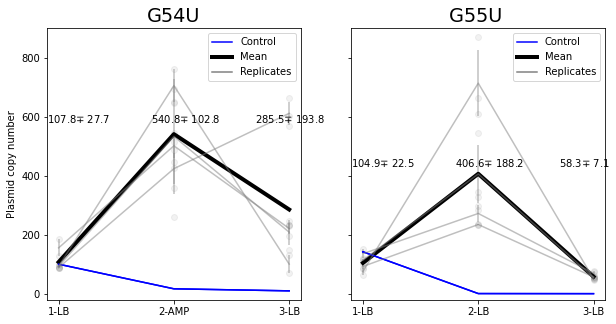

In [ ]:

fig,ax=plt.subplots(1,2,figsize=(10,5),sharey=True)
fig.set_facecolor('white')
plt.rcParams.update({'font.size': 16})


col_mean=[]
col_std=[]
for row in range(0,len(G54_control_days_dxs)):
    row_mean_d=[]
    row_mean_t=[]
    row_mean_cn=[]
    for ci,col in enumerate(G54_control_repsT):
        well_d=G54_control_days_dxs[row]+str(col)
        well_t=G54_control_days_tem[row]+str(col)
        ct_d=list(G54_df_all[G54_df_all["Well"]==well_d]["Cq"])[0]
        ct_t=list(G54_df_all[G54_df_all["Well"]==well_t]["Cq"])[0]
        cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
        if(np.isnan(cn_eff)):
            continue
        row_mean_d.append(ct_d)
        row_mean_t.append(ct_t)
        row_mean_cn.append(cn_eff)
        
    mean_d=np.mean(row_mean_d)
    mean_t=np.mean(row_mean_t)
    mean_cn=np.mean(row_mean_cn)
    col_mean.append(mean_cn)
    std_cn=np.std(row_mean_cn)
    col_std.append(std_cn)

ax[0].plot([1,2,3],col_mean,c='blue',label="Control")   
ax[0].errorbar([1,2,3],col_mean,yerr=col_std,c='blue')   
# for x in range(1,4):
#     m=round(col_mean[x-1],1)
#     ax[1].text(x-.1,m+25,'%s'%(m))

normv=1

all_means=[]
for ri in range(0,len(G54_repsB_dxs)):
    bio_mean_cn=[]
    bio_std_cn=[]
    for di,day in enumerate(G54_days):
        tech_mean_d=[]
        tech_mean_t=[]
        tech_mean_cn=[]
        for ci,col in enumerate(day):
            well_d=G55_repsB_dxs[ri]+col
            well_t=G55_repsB_tem[ri]+col
            ct_d=list(G54_df_all[G54_df_all["Well"]==well_d]["Cq"])[0]
            ct_t=list(G54_df_all[G54_df_all["Well"]==well_t]["Cq"])[0]
            cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
            #normv=col_mean[0]
            cn_eff=cn_eff/normv
            
            if(np.isnan(cn_eff)):
                #print("xxx",well_d, well_t)
                continue
            if(well_d in G55_ex_wells or well_t in G55_ex_wells):
                #print("xxxxx",well_d, well_t)
                continue
            tech_mean_d.append(ct_d)
            tech_mean_t.append(ct_t)
            tech_mean_cn.append(cn_eff)
            ax[0].scatter(di+1,cn_eff,c="gray",alpha=.1)
        mean_d=np.mean(tech_mean_d)
        mean_t=np.mean(tech_mean_t)
    
        mean_cn=np.mean(tech_mean_cn)
        std_cn=np.std(tech_mean_cn)
        bio_mean_cn.append(mean_cn)
        bio_std_cn.append(std_cn)
        
    all_means.append(bio_mean_cn)
    ax[0].errorbar([1,2,3],bio_mean_cn,yerr=bio_std_cn,c="gray",alpha=.5)#,marker=(5, 2),label="Rep-%s"%ri)
y1=[x[0] for x in all_means]    
y2=[x[1] for x in all_means]    
y3=[x[2] for x in all_means]
ys=[y1,y2,y3]
means=[np.mean(y) for y in ys]
stds=[np.std(y) for y in ys]
ax[0].plot([1,2,3],means,c='k',lw=4,label="Mean")


ax[0].set_title("G55U")
for x in range(1,4):
    m=round(means[x-1],1)
    s=round(stds[x-1],1)
    ax[0].text(x-(.1*x),580,r'%s$\mp$ %s'%(m,s),fontsize=10)


################################# G55

col_mean=[]
col_std=[]

for row in range(0,len(G55_control_days_dxs)):
    row_mean_d=[]
    row_mean_t=[]
    row_mean_cn=[]
    for ci,col in enumerate(G55_control_repsT):
        well_d=G55_control_days_dxs[row]+str(col)
        well_t=G55_control_days_tem[row]+str(col)
        ct_d=list(G55_df_all[G55_df_all["Well"]==well_d]["Cq"])[0]
        ct_t=list(G55_df_all[G55_df_all["Well"]==well_t]["Cq"])[0]
        cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
        
 
        if(np.isnan(cn_eff)):
            continue
        row_mean_d.append(ct_d)
        row_mean_t.append(ct_t)
        row_mean_cn.append(cn_eff)
        
    mean_d=np.mean(row_mean_d)
    mean_t=np.mean(row_mean_t)
    mean_cn=np.mean(row_mean_cn)
    col_mean.append(mean_cn)
    std_cn=np.std(row_mean_cn)
    col_std.append(std_cn)

ax[1].plot([1,2,3],col_mean,c='blue',label="Control")   
ax[1].errorbar([1,2,3],col_mean,yerr=col_std,c='blue')   
# # for x in range(1,4):
# #     m=round(col_mean[x-1],1)
# #     ax[1].text(x-.1,m+25,'%s'%(m))

# normv=1

all_means=[]
for ri in range(0,len(G55_repsB_dxs)):
    bio_mean_cn=[]
    bio_std_cn=[]
    for di,day in enumerate(G55_days):
        tech_mean_d=[]
        tech_mean_t=[]
        tech_mean_cn=[]
        for ci,col in enumerate(day):
            well_d=G55_repsB_dxs[ri]+col
            well_t=G55_repsB_tem[ri]+col
            ct_d=list(G55_df_all[G55_df_all["Well"]==well_d]["Cq"])[0]
            ct_t=list(G55_df_all[G55_df_all["Well"]==well_t]["Cq"])[0]
            cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
            #normv=col_mean[0]
            cn_eff=cn_eff/normv
            
            if(np.isnan(cn_eff)):
                #print("xxx",well_d, well_t)
                continue
            if(well_d in G55_ex_wells or well_t in G55_ex_wells):
                #print("xxxxx",well_d, well_t)
                continue
            tech_mean_d.append(ct_d)
            tech_mean_t.append(ct_t)
            tech_mean_cn.append(cn_eff)
            ax[1].scatter(di+1,cn_eff,c="gray",alpha=.1)
        mean_d=np.mean(tech_mean_d)
        mean_t=np.mean(tech_mean_t)
    
        mean_cn=np.mean(tech_mean_cn)
        std_cn=np.std(tech_mean_cn)
        bio_mean_cn.append(mean_cn)
        bio_std_cn.append(std_cn)
        
    all_means.append(bio_mean_cn)
    ax[1].errorbar([1,2,3],bio_mean_cn,yerr=bio_std_cn,c="gray",alpha=.5)#,marker=(5, 2),label="Rep-%s"%ri)
y1=[x[0] for x in all_means]    
y2=[x[1] for x in all_means]    
y3=[x[2] for x in all_means]
ys=[y1,y2,y3]
means=[np.mean(y) for y in ys]
stds=[np.std(y) for y in ys]
ax[1].plot([1,2,3],means,c='k',lw=4,label="Mean")






ax[0].plot([1,2,3],[-100,-100,-100],c='gray',label="Replicates")
ax[1].plot([1,2,3],[-100,-100,-100],c='gray',label="Replicates")
ax[0].set_ylim([-20,900])

ax[1].set_xticks([1,2,3])
ax[1].set_xticklabels(xs)
ax[1].set_title("G55U ")


xs=["1-LB","2-AMP","3-LB"]
ax[0].set_xticks([1,2,3])
ax[0].set_xticklabels(xs)
ax[0].set_ylabel("Plasmid copy number")
ax[0].set_title("G54U")
for x in range(1,4):
    m=round(means[x-1],1)
    s=round(stds[x-1],1)
    ax[1].text(x-(.1*x),430,r'%s$\mp$ %s'%(m,s),fontsize=10)

ax[0].legend(fontsize=10)
ax[1].legend(fontsize=10)

#ax[1].set_yscale("log")

print("Saving fig as: \n",out_fig_name)
#plt.savefig(out_fig_name,bbox_inches = 'tight',pad_inches = 0.1)

plt.show()



Saving fig as: 
 /content/drive/MyDrive/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig_G54U_G55U.pdf


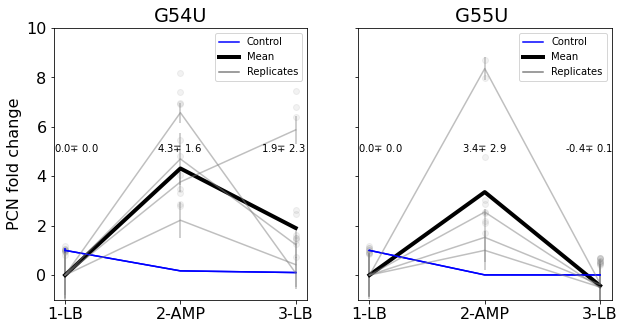

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(10,5),sharey=True)
fig.set_facecolor('white')
plt.rcParams.update({'font.size': 16})


col_mean=[]
col_std=[]
for row in range(0,len(G54_control_days_dxs)):
    row_mean_d=[]
    row_mean_t=[]
    row_mean_cn=[]
    for ci,col in enumerate(G54_control_repsT):
        well_d=G54_control_days_dxs[row]+str(col)
        well_t=G54_control_days_tem[row]+str(col)
        ct_d=list(G54_df_all[G54_df_all["Well"]==well_d]["Cq"])[0]
        ct_t=list(G54_df_all[G54_df_all["Well"]==well_t]["Cq"])[0]
        cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
        if(np.isnan(cn_eff)):
            continue
        row_mean_d.append(ct_d)
        row_mean_t.append(ct_t)
        row_mean_cn.append(cn_eff)
        
    mean_d=np.mean(row_mean_d)
    mean_t=np.mean(row_mean_t)
    mean_cn=np.mean(row_mean_cn)
    col_mean.append(mean_cn)
    std_cn=np.std(row_mean_cn)
    col_std.append(std_cn)

col_std=[x/col_mean[0] for x in col_std]
col_mean=[x/col_mean[0] for x in col_mean]

ax[0].plot([1,2,3],col_mean,c='blue',label="Control")   
ax[0].errorbar([1,2,3],col_mean,yerr=col_std,c='blue')   
# for x in range(1,4):
#     m=round(col_mean[x-1],1)
#     ax[1].text(x-.1,m+25,'%s'%(m))

normv=1

all_means=[]
for ri in range(0,len(G54_repsB_dxs)):
    bio_mean_cn=[]
    bio_std_cn=[]
    for di,day in enumerate(G54_days):
        tech_mean_d=[]
        tech_mean_t=[]
        tech_mean_cn=[]
        for ci,col in enumerate(day):
            well_d=G55_repsB_dxs[ri]+col
            well_t=G55_repsB_tem[ri]+col
            ct_d=list(G54_df_all[G54_df_all["Well"]==well_d]["Cq"])[0]
            ct_t=list(G54_df_all[G54_df_all["Well"]==well_t]["Cq"])[0]
            cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
                        
            if(np.isnan(cn_eff)):
                #print("xxx",well_d, well_t)
                continue
            if(well_d in G55_ex_wells or well_t in G55_ex_wells):
                #print("xxxxx",well_d, well_t)
                continue
            tech_mean_d.append(ct_d)
            tech_mean_t.append(ct_t)
            tech_mean_cn.append(cn_eff)
            ax[0].scatter(di+1,cn_eff,c="gray",alpha=.1)
        mean_d=np.mean(tech_mean_d)
        mean_t=np.mean(tech_mean_t)
    
        mean_cn=np.mean(tech_mean_cn)
        std_cn=np.std(tech_mean_cn)
        bio_mean_cn.append(mean_cn)
        bio_std_cn.append(std_cn)
   
        tech_mean_cnN=[x/bio_mean_cn[0] for x in tech_mean_cn]
        ax[0].scatter([di+1]*len(tech_mean_cnN),tech_mean_cnN,c="gray",alpha=.1)       
        
    #bio_std_cn=[x/bio_mean_cn[0] for x in bio_std_cn]
    #bio_mean_cn=[x/bio_mean_cn[0] for x in bio_mean_cn]
    bio_std_cn=[(x-bio_mean_cn[0])/bio_mean_cn[0] for x in bio_std_cn]
    bio_mean_cn=[(x-bio_mean_cn[0])/bio_mean_cn[0] for x in bio_mean_cn]
    
    all_means.append(bio_mean_cn)

    ax[0].errorbar([1,2,3],bio_mean_cn,yerr=bio_std_cn,c="gray",alpha=.5)#,marker=(5, 2),label="Rep-%s"%ri)
y1=[x[0] for x in all_means]    
y2=[x[1] for x in all_means]    
y3=[x[2] for x in all_means]
ys=[y1,y2,y3]
means=[np.mean(y) for y in ys]
stds=[np.std(y) for y in ys]
ax[0].plot([1,2,3],means,c='k',lw=4,label="Mean")


ax[0].set_title("G55U")
for x in range(1,4):
    m=round(means[x-1],1)
    s=round(stds[x-1],1)
    ax[0].text(x-(.1*x),5,r'%s$\mp$ %s'%(m,s),fontsize=10)


################################# G55

col_mean=[]
col_std=[]

for row in range(0,len(G55_control_days_dxs)):
    row_mean_d=[]
    row_mean_t=[]
    row_mean_cn=[]
    for ci,col in enumerate(G55_control_repsT):
        well_d=G55_control_days_dxs[row]+str(col)
        well_t=G55_control_days_tem[row]+str(col)
        ct_d=list(G55_df_all[G55_df_all["Well"]==well_d]["Cq"])[0]
        ct_t=list(G55_df_all[G55_df_all["Well"]==well_t]["Cq"])[0]
        cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
        
 
        if(np.isnan(cn_eff)):
            continue
        row_mean_d.append(ct_d)
        row_mean_t.append(ct_t)
        row_mean_cn.append(cn_eff)
        
    mean_d=np.mean(row_mean_d)
    mean_t=np.mean(row_mean_t)
    mean_cn=np.mean(row_mean_cn)
    col_mean.append(mean_cn)
    std_cn=np.std(row_mean_cn)
    col_std.append(std_cn)

col_std=[x/col_mean[0] for x in col_std]
col_mean=[x/col_mean[0] for x in col_mean]

ax[1].plot([1,2,3],col_mean,c='blue',label="Control")   
ax[1].errorbar([1,2,3],col_mean,yerr=col_std,c='blue')   
# # for x in range(1,4):
# #     m=round(col_mean[x-1],1)
# #     ax[1].text(x-.1,m+25,'%s'%(m))

# normv=1

all_means=[]
for ri in range(0,len(G55_repsB_dxs)):
    bio_mean_cn=[]
    bio_std_cn=[]
    for di,day in enumerate(G55_days):
        tech_mean_d=[]
        tech_mean_t=[]
        tech_mean_cn=[]
        for ci,col in enumerate(day):
            well_d=G55_repsB_dxs[ri]+col
            well_t=G55_repsB_tem[ri]+col
            ct_d=list(G55_df_all[G55_df_all["Well"]==well_d]["Cq"])[0]
            ct_t=list(G55_df_all[G55_df_all["Well"]==well_t]["Cq"])[0]
            cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
            normv=col_mean[0]
            cn_eff=cn_eff/normv
            
            if(np.isnan(cn_eff)):
                #print("xxx",well_d, well_t)
                continue
            if(well_d in G55_ex_wells or well_t in G55_ex_wells):
                #print("xxxxx",well_d, well_t)
                continue
            tech_mean_d.append(ct_d)
            tech_mean_t.append(ct_t)
            tech_mean_cn.append(cn_eff)
        
        mean_d=np.mean(tech_mean_d)
        mean_t=np.mean(tech_mean_t)
    
        mean_cn=np.mean(tech_mean_cn)
        std_cn=np.std(tech_mean_cn)
        bio_mean_cn.append(mean_cn)
        bio_std_cn.append(std_cn)

        tech_mean_cnN=[x/bio_mean_cn[0] for x in tech_mean_cn]
        ax[1].scatter([di+1]*len(tech_mean_cnN),tech_mean_cnN,c="gray",alpha=.1)       
        

    #bio_std_cn=[x/bio_mean_cn[0] for x in bio_std_cn]
    #bio_mean_cn=[x/bio_mean_cn[0] for x in bio_mean_cn]
    bio_std_cn=[(x-bio_mean_cn[0])/bio_mean_cn[0] for x in bio_std_cn]
    bio_mean_cn=[(x-bio_mean_cn[0])/bio_mean_cn[0] for x in bio_mean_cn]

    all_means.append(bio_mean_cn)

    ax[1].errorbar([1,2,3],bio_mean_cn,yerr=bio_std_cn,c="gray",alpha=.5)#,marker=(5, 2),label="Rep-%s"%ri)
y1=[x[0] for x in all_means]    
y2=[x[1] for x in all_means]    
y3=[x[2] for x in all_means]
ys=[y1,y2,y3]
means=[np.mean(y) for y in ys]
stds=[np.std(y) for y in ys]
ax[1].plot([1,2,3],means,c='k',lw=4,label="Mean")






ax[0].plot([1,2,3],[-100,-10,-10],c='gray',label="Replicates")
ax[1].plot([1,2,3],[-100,-10,-10],c='gray',label="Replicates")
ax[0].set_ylim([-1,10])

ax[1].set_xticks([1,2,3])
ax[1].set_xticklabels(xs)
ax[1].set_title("G55U ")


xs=["1-LB","2-AMP","3-LB"]
ax[0].set_xticks([1,2,3])
ax[0].set_xticklabels(xs)
ax[0].set_ylabel("PCN fold change")
ax[0].set_title("G54U")
for x in range(1,4):
    m=round(means[x-1],1)
    s=round(stds[x-1],1)
    ax[1].text(x-(.1*x),5,r'%s$\mp$ %s'%(m,s),fontsize=10)

ax[0].legend(fontsize=10)
ax[1].legend(fontsize=10)

#ax[1].set_yscale("log")

print("Saving fig as: \n",out_fig_name)
#plt.savefig(out_fig_name,bbox_inches = 'tight',pad_inches = 0.1)

plt.show()



## Flow Cytometry

### G54U

In [ ]:
G54_file=amnis_raw_data_path+"G54U_LB-AMP-LB_AMNIS.csv"
G54_AMNIS_df=pd.read_csv(G54_file,sep="\t")
G54_AMNIS_dfbk=G54_AMNIS_df.copy()

G54_AMNIS_df.head()

,Object Number,Area_M01,Area_M02,Aspect Ratio_M01,Aspect Ratio_M02,Gradient RMS_M01_Ch01,Gradient RMS_M02_Ch02,Intensity_MC_Ch01,Intensity_MC_Ch02,replicate,season,strain,treatment
0,0,11.333333,12.888889,0.931394,0.984125,72.269453,43.365689,1329.500000,44738.500000,rep-4,3,G54U,LB
1,1,28.222222,23.222222,0.566803,0.559159,68.884599,37.017296,2175.268293,84527.741935,rep-4,3,G54U,LB
2,2,19.000000,17.888889,0.826972,0.745027,66.725949,39.671668,1751.032407,67030.509259,rep-4,3,G54U,LB
3,3,30.555556,25.888889,0.466730,0.392182,71.041353,36.520460,2117.648438,85331.625000,rep-4,3,G54U,LB
4,4,20.777778,13.444444,0.725542,0.701453,70.179236,35.136057,491.182692,18733.576923,rep-4,3,G54U,LB


-80.4051724137933 342121.562500002
-42.4117647058822 396711.561170211
-17.6442307692308 382982.79166666704


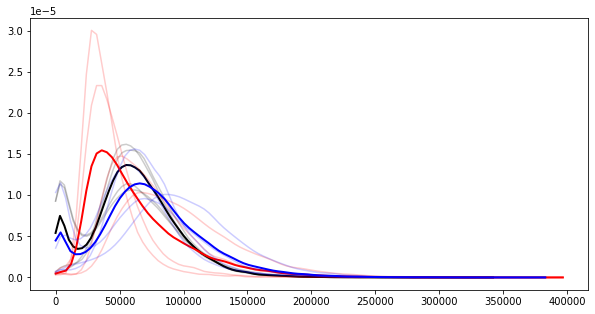

In [ ]:
colors=["k","red","blue"]
seasons=G54_AMNIS_df["season"].unique()
seasons.sort()

G54_AMNIS_df=G54_AMNIS_dfbk.copy()
G54_AMNIS_df=G54_AMNIS_df[G54_AMNIS_df["replicate"]!="Control"]


fig,ax=plt.subplots(figsize=(10,5)) 
for ic,season in enumerate(seasons):
    season_df=G54_AMNIS_df[G54_AMNIS_df["season"]==season]
    this_gs=season_df["Intensity_MC_Ch02"]
    maxg=this_gs.max()
    ming=this_gs.min()
    print(ming,maxg)
    xs=np.linspace(ming,maxg,100)

    den=gaussian_kde(this_gs)
    ys=den(xs)
    ax.plot(xs,ys,lw=2,c=colors[ic])
    reps=season_df["replicate"].unique()
    for rep in reps:
        t_df=season_df[season_df["replicate"]==rep]
        this_gs=t_df["Intensity_MC_Ch02"]
        den=gaussian_kde(this_gs)
        ys=den(xs)
        ax.plot(xs,ys,c=colors[ic],alpha=.2)
#plt.yscale("log")
#plt.xscale("log")
plt.show()

50000.3625000001 382982.79166666704
[1 2 3]


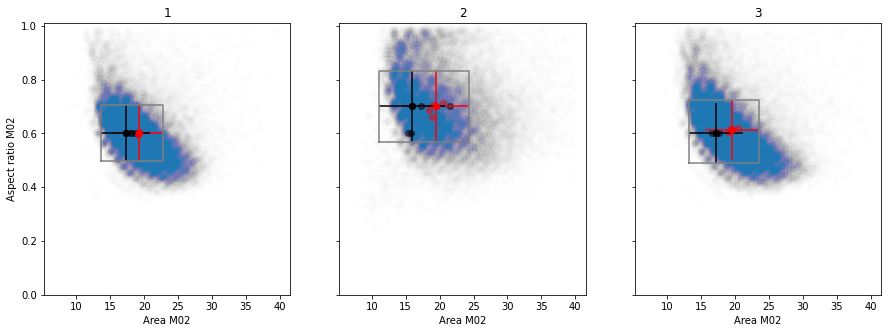

In [ ]:
seasons=G54_AMNIS_df["season"].unique()
seasons.sort()
nseasons=len(seasons)
rows=[1]
nrows=len(rows)

G54_AMNIS_df=G54_AMNIS_dfbk.copy()
G54_AMNIS_df=G54_AMNIS_df[G54_AMNIS_df["replicate"]!="Control"]

G54_AMNIS_df=G54_AMNIS_df[(G54_AMNIS_df["Intensity_MC_Ch02"]>50000)
                          &(G54_AMNIS_df["Area_M02"]<40) #40
                          ]


G54_AMNIS_df.round({"Area_M02":1,"Aspect Ratio_M02":2})

this_g=G54_AMNIS_df["Intensity_MC_Ch02"]
maxg=this_g.max()
ming=this_g.min()
print(ming,maxg)
print(seasons)
#ming=0
#maxg=500000

xs=np.linspace(ming,maxg,100)


G54_AMNIS_dflims={}
for season in seasons:
    G54_AMNIS_dflims[season]={}
    
fig,ax=plt.subplots(nrows,nseasons,figsize=(nseasons*5,nrows*5),sharey=True,sharex=True) 
for ic,season in enumerate(seasons):
    season_df=G54_AMNIS_df[(G54_AMNIS_df["season"]==season)
                &(G54_AMNIS_df["Area_M02"]<100) #40
                #&(G54_AMNIS_df["Aspect Ratio_M02"]>.35)
                #&(G54_AMNIS_df["Gradient RMS_M02_Ch02"]>40)
                ]
    ax[ic].set_title(season)

    
    xs=season_df["Area_M02"]
    ys=season_df["Aspect Ratio_M02"]
    ax[ic].scatter(xs,ys,alpha=.005)
    
    xs=[round(x,1) for x in list(season_df["Area_M02"])]
    xm=np.mean(xs)
    ys=[round(x,1) for x in list(season_df["Aspect Ratio_M02"])]
    ym=np.mean(ys)
    #print(x,y,end="\t")
    ax[ic].scatter(xm,ym,c='r',alpha=1)
    xsd=np.std(xs)
    ysd=np.std(ys)
    ax[ic].errorbar(xm, ym,xerr=xsd ,yerr=ysd,c='r',fmt='-o')
    
    xmo=stats.mode(xs).mode[0]
    ymo=stats.mode(ys).mode[0]
    #print(x,y)
    ax[ic].scatter(xmo,ymo,c='k',alpha=1)
    ax[ic].errorbar(xmo, ymo,xerr=xsd ,yerr=ysd,c='k',fmt='-o')
    reps=season_df["replicate"].unique()
    nsds=1
    max_x=max(xmo+nsds*xsd,xm+nsds*xsd)
    min_x=min(xmo-xsd,xm-xsd)
    max_y=max(ymo+nsds*ysd,ym+nsds*ysd)
    min_y=min(ymo-ysd,ym-ysd)
    G54_AMNIS_dflims[season]["Area"]=[min_x,max_x]
    G54_AMNIS_dflims[season]["Aspect"]=[min_y,max_y]
    ax[ic].plot([min_x,max_x,max_x,min_x,min_x],[min_y,min_y,max_y,max_y,min_y],c='gray')

    for rep in reps:
        t_df=season_df[season_df["replicate"]==rep]
        xs=[round(x,1) for x in list(t_df["Area_M02"])]
        x=np.mean(xs)
        ys=[round(x,1) for x in list(t_df["Aspect Ratio_M02"])]
        y=np.mean(ys)
        #print(x,y,end="\t")
        ax[ic].scatter(x,y,c='r',alpha=.5)
        x=stats.mode(xs).mode
        y=stats.mode(ys).mode
        #print(x,y)
        ax[ic].scatter(x,y,c='k',alpha=.5)
    ax[ic].set_xlabel("Area M02")
#ax[0].set_xlim([0,50])
ax[0].set_ylim([0,1.01])
ax[0].set_ylabel("Aspect ratio M02")

plt.show()



20000.1944444445 382982.79166666704
[1 2 3]


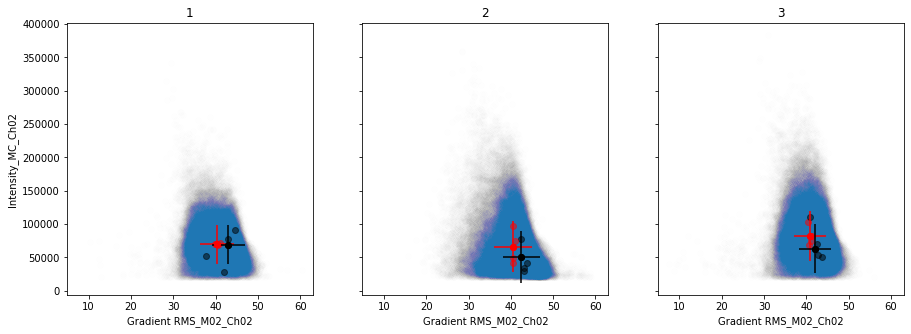

40.355644245233776 69813.1358302889
	 41.01254517294786 72258.62101187403	[44.6] [91207.]
	 39.9664897103159 70007.72468213396	[37.7] [51984.2]
	 40.50554659451585 68161.66032051615	[43.] [77045.5]
	 40.115304247388046 69831.4716490786	[41.9] [28241.4]

40.577773600560036 66003.20724415981
	 40.491053699156616 42200.835128643106	[43.9] [42027.5]
	 40.49569193253404 97343.4479221703	[42.3] [77458.9]
	 40.877165832195416 74008.3600262985	[43.] [33991.1]
	 40.43634876233705 48624.543378899034	[43.] [29932.7]

40.81561324144929 82336.20397976294
	 40.671780900487526 68675.00466876972	[42.5] [69824.3]
	 41.048770961358194 74543.13973544422	[42.7] [53855.3]
	 41.24786419833845 82725.24504480932	[43.7] [51263.]
	 40.36501182033097 102398.09832413973	[40.8] [109883.1]



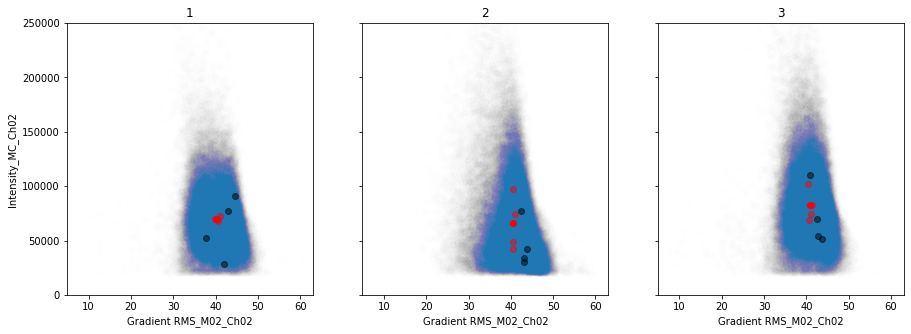

In [ ]:
seasons=G54_AMNIS_df["season"].unique()
seasons.sort()
nseasons=len(seasons)
rows=[1]
nrows=len(rows)

G54_AMNIS_df=G54_AMNIS_dfbk.copy()
G54_AMNIS_df=G54_AMNIS_df[G54_AMNIS_df["replicate"]!="Control"]

G54_AMNIS_df=G54_AMNIS_df[(G54_AMNIS_df["Intensity_MC_Ch02"]>20000)
                          &(G54_AMNIS_df["Area_M02"]<40) #40
                          ]


G54_AMNIS_df.round({"Area_M02":1,"Aspect Ratio_M02":2})

this_g=G54_AMNIS_df["Intensity_MC_Ch02"]
maxg=this_g.max()
ming=this_g.min()
print(ming,maxg)
print(seasons)
#ming=0
#maxg=500000

xs=np.linspace(ming,maxg,100)

    
fig,ax=plt.subplots(nrows,nseasons,figsize=(nseasons*5,nrows*5),sharey=True,sharex=True) 
for ic,season in enumerate(seasons):
    season_df=G54_AMNIS_df[(G54_AMNIS_df["season"]==season)
                &(G54_AMNIS_df["Area_M02"]<100) #40
                #&(G54_AMNIS_df["Aspect Ratio_M02"]>.35)
                #&(G54_AMNIS_df["Gradient RMS_M02_Ch02"]>40)
                ]
    ax[ic].set_title(season)

    
    xs=season_df["Gradient RMS_M02_Ch02"]
    ys=season_df["Intensity_MC_Ch02"]
    ax[ic].scatter(xs,ys,alpha=.005)
    
    xs=[round(x,1) for x in list(season_df["Gradient RMS_M02_Ch02"])]
    xm=np.mean(xs)
    ys=[round(x,1) for x in list(season_df["Intensity_MC_Ch02"])]
    ym=np.mean(ys)
    
    ax[ic].scatter(xm,ym,c='r',alpha=1)
    xsd=np.std(xs)
    ysd=np.std(ys)
    ax[ic].errorbar(xm, ym,xerr=xsd ,yerr=ysd,c='r',fmt='-o')
    
    xmo=stats.mode(xs).mode[0]
    ymo=stats.mode(ys).mode[0]
    #print(x,y)
    ax[ic].scatter(xmo,ymo,c='k',alpha=1)
    ax[ic].errorbar(xmo, ymo,xerr=xsd ,yerr=ysd,c='k',fmt='-o')
    reps=season_df["replicate"].unique()
    
    for rep in reps:
        t_df=season_df[season_df["replicate"]==rep]
        xs=[round(x,1) for x in list(t_df["Gradient RMS_M02_Ch02"])]
        x=np.mean(xs)
        ys=[round(x,1) for x in list(t_df["Intensity_MC_Ch02"])]
        y=np.mean(ys)
        #print(x,y,end="\t")
        ax[ic].scatter(x,y,c='r',alpha=.5)
        x=stats.mode(xs).mode
        y=stats.mode(ys).mode
        #print(x,y)
        ax[ic].scatter(x,y,c='k',alpha=.5)
    ax[ic].set_xlabel("Gradient RMS_M02_Ch02")
#ax[0].set_xlim([0,50])
#ax[0].set_ylim([0,1.01])
ax[0].set_ylabel("Intensity_MC_Ch02")

plt.show()

fig,ax=plt.subplots(nrows,nseasons,figsize=(nseasons*5,nrows*5),sharey=True,sharex=True) 
for ic,season in enumerate(seasons):
    season_df=G54_AMNIS_df[(G54_AMNIS_df["season"]==season)
                &(G54_AMNIS_df["Area_M02"]<100) #40
                #&(G54_AMNIS_df["Aspect Ratio_M02"]>.35)
                #&(G54_AMNIS_df["Gradient RMS_M02_Ch02"]>40)
                ]
    ax[ic].set_title(season)

    
    xs=season_df["Gradient RMS_M02_Ch02"]
    ys=season_df["Intensity_MC_Ch02"]
    ax[ic].scatter(xs,ys,alpha=.002)
    
    xs=[round(x,1) for x in list(season_df["Gradient RMS_M02_Ch02"])]
    xm=np.mean(xs)
    ys=[round(x,1) for x in list(season_df["Intensity_MC_Ch02"])]
    ym=np.mean(ys)
    print(xm,ym)
    ax[ic].scatter(xm,ym,c='r',alpha=1)
    xsd=np.std(xs)
    ysd=np.std(ys)
    
    reps=season_df["replicate"].unique()
    for rep in reps:
        t_df=season_df[season_df["replicate"]==rep]
        xs=[round(x,1) for x in list(t_df["Gradient RMS_M02_Ch02"])]
        x=np.mean(xs)
        ys=[round(x,1) for x in list(t_df["Intensity_MC_Ch02"])]
        y=np.mean(ys)
        print("\t",x,y,end="\t")
        ax[ic].scatter(x,y,c='r',alpha=.5)
        x=stats.mode(xs).mode
        y=stats.mode(ys).mode
        print(x,y)
        ax[ic].scatter(x,y,c='k',alpha=.5)
    ax[ic].set_xlabel("Gradient RMS_M02_Ch02")
    print()
#ax[0].set_xlim([0,50])
ax[0].set_ylim([0,250000])
ax[0].set_ylabel("Intensity_MC_Ch02")

plt.show()


In [ ]:
G54_AMNIS_dflims

{1: {'Area': [13.675477992250887, 22.812448758077988],
  'Aspect': [0.4956431379640457, 0.7043798308609944]},
 2: {'Area': [11.045549140009246, 24.333624686370573],
  'Aspect': [0.5694279229564989, 0.832482861289841]},
 3: {'Area': [13.220972051846303, 23.556624179972744],
  'Aspect': [0.4880472662013495, 0.7249929863910002]}}

-1000 300000.0
13.675477992250887 22.812448758077988 0.4956431379640457 0.7043798308609944
36259 67709.2676938102 22978.725428729547 0.33937341535936005
	 6599 68092.12619797 26100.64919205235 0.3833137640050734
	 8838 65295.20660786175 26755.13869330843 0.40975655156418517
	 10359 67833.57006163937 19515.833490576544 0.2877017009843768
	 10463 69383.86774927357 20263.156131190237 0.2920441997326156

11.045549140009246 24.333624686370573 0.5694279229564989 0.832482861289841
40519 64247.46853364781 27229.070323794273 0.4238154583403362
	 9591 43953.943550263975 15409.719680216036 0.3505878752971072
	 10504 86249.74692758975 27120.656496450247 0.3144433167927921
	 11879 70678.55066358695 22871.905127880207 0.32360461431566445
	 8545 51038.39202623234 18124.347136357854 0.35511203266439967

13.220972051846303 23.556624179972744 0.4880472662013495 0.7249929863910002
43614 77312.01481928481 28331.918866064865 0.3664620425724271
	 10294 66129.68952158961 24056.857429392825 0.3637830088638007

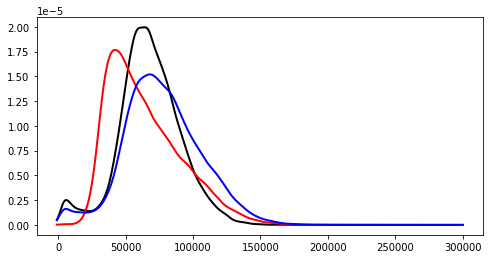

In [ ]:
seasons=G54_AMNIS_df["season"].unique()
seasons.sort()

G54_AMNIS_df=G54_AMNIS_dfbk.copy()
G54_AMNIS_df=G54_AMNIS_df[G54_AMNIS_df["replicate"]!="Control"]

G54_AMNIS_df.round({"Area_M02":1,"Aspect Ratio_M02":2})

lim_aspect=[.05, 1];
lim_area=[25, 35];


# G54_AMNIS_df=G54_AMNIS_df[
#                 #(G54_AMNIS_df["Area_M02"]>lim_area[0])&(G54_AMNIS_df["Area_M02"]<lim_area[1])
#                 #&(G54_AMNIS_df["Aspect Ratio_M02"]>lim_aspect[0])&(G54_AMNIS_df["Aspect Ratio_M02"]<lim_aspect[1])
#                 (G54_AMNIS_df["Gradient RMS_M02_Ch02"]>30)
#                 ]
G54_AMNIS_df=G54_AMNIS_df[
                        (G54_AMNIS_df["Intensity_MC_Ch02"]>500)
                        # &(G54_AMNIS_df["Area_M02"]<40) #40
                          &(G54_AMNIS_df["Gradient RMS_M02_Ch02"]<50)
                          &(G54_AMNIS_df["Gradient RMS_M02_Ch02"]>30)
                          ]


this_g=G54_AMNIS_df["Intensity_MC_Ch02"]
maxg=this_g.max()
ming=this_g.min()
ming=-1000
maxg=3e5

print(ming,maxg)
xs=np.linspace(ming,maxg,1000)

fig,ax=plt.subplots(figsize=(8,4)) 
for ic,season in enumerate(seasons):
    season_df=G54_AMNIS_df[G54_AMNIS_df["season"]==season]
    #season_df=season_df[season_df["Intensity_MC_Ch02"]<maxg]
    [area_min,area_max]=G54_AMNIS_dflims[season]["Area"]
    [aspect_min,aspect_max]=G54_AMNIS_dflims[season]["Aspect"]
    print("", area_min,area_max,aspect_min,aspect_max)
    season_df=season_df[(season_df["Area_M02"]>area_min)&(season_df["Area_M02"]<area_max)
               &(season_df["Aspect Ratio_M02"]>aspect_min)&(season_df["Aspect Ratio_M02"]<aspect_max)
               ]

    this_gs=season_df["Intensity_MC_Ch02"]
    this_mean=np.mean(this_gs)
    this_sd=np.std(this_gs)
    this_cv=this_sd/this_mean
    print(this_gs.size,this_mean,this_sd,this_cv)
    this_gs2=[int(x) for x in this_gs]
    den=gaussian_kde(this_gs2)
    ys=den(xs)
    yma=max(ys)
    
    ax.plot(xs,ys,lw=2,c=colors[ic])
    xmode=stats.mode(this_gs2).mode
    #ax.vlines(x=xmode,ymin=0,ymax=yma,lw=ic*.25)
    reps=season_df["replicate"].unique()
    
    for rep in reps:
        t_df=season_df[season_df["replicate"]==rep]
        this_gs=t_df["Intensity_MC_Ch02"]
        this_mean=np.mean(this_gs)
        this_sd=np.std(this_gs)
        this_cv=this_sd/this_mean
        print("\t",this_gs.size,this_mean,this_sd,this_cv)
        #ax.plot(xs,ys,c='k',alpha=.2)
    
    print()


#plt.yscale("log")
#plt.xscale("log")
plt.show()



-1000 300000.0
13.675477992250887 22.812448758077988 0.4956431379640457 0.7043798308609944
10538 71336.30719113674 18221.560608259508 0.25543178958559076
	 2328 74182.4377630721 18974.919500047792 0.25578721961997153
	 2047 72032.70167122713 18460.799079540167 0.25628358580522576
	 3237 68956.43248984283 17623.841260178924 0.25557936546057375
	 2926 71217.49069622008 17726.510674087633 0.24890670115997895

11.045549140009246 24.333624686370573 0.5694279229564989 0.832482861289841
16238 59406.32102283399 23326.803856503455 0.39266535033430766
	 3599 41415.9013092366 11046.81693769339 0.266728879210211
	 4217 77621.44208643411 23673.095230749717 0.3049813890907737
	 5369 65277.926693260524 20315.400257220394 0.31121393227885424
	 3053 45128.4645470777 12085.70386231232 0.2678066711023283

13.220972051846303 23.556624179972744 0.4880472662013495 0.7249929863910002
14760 78694.47050068104 23923.834134119064 0.30400908706682284
	 2980 68214.92845299734 20086.194663609615 0.2944545295162152


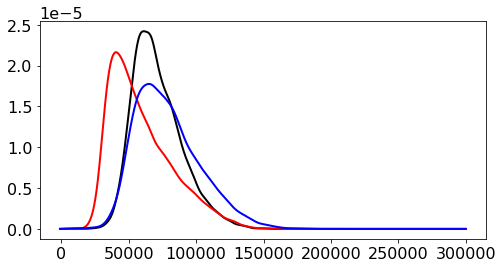

In [ ]:
seasons=G54_AMNIS_df["season"].unique()
seasons.sort()

G54_AMNIS_df=G54_AMNIS_dfbk.copy()
G54_AMNIS_df=G54_AMNIS_df[G54_AMNIS_df["replicate"]!="Control"]

G54_AMNIS_df.round({"Area_M02":1,"Aspect Ratio_M02":2})

lim_aspect=[.05, 1];
lim_area=[5, 25];


G54_AMNIS_df=G54_AMNIS_df[
                #(G54_AMNIS_df["Area_M02"]>lim_area[0])&(G54_AMNIS_df["Area_M02"]<lim_area[1])
                #&(G54_AMNIS_df["Aspect Ratio_M02"]>lim_aspect[0])&(G54_AMNIS_df["Aspect Ratio_M02"]<lim_aspect[1])
                (G54_AMNIS_df["Gradient RMS_M02_Ch02"]>42)
                &(G54_AMNIS_df["Gradient RMS_M01_Ch01"]>69)&(G54_AMNIS_df["Gradient RMS_M01_Ch01"]<78)
                &(G54_AMNIS_df["Area_M01"]>4) &( G54_AMNIS_df["Area_M01"]<25)
                &(G54_AMNIS_df["Aspect Ratio_M01"]>.1)&(G54_AMNIS_df["Aspect Ratio_M01"]<1)
                ]



this_g=G54_AMNIS_df["Intensity_MC_Ch02"]
maxg=this_g.max()
ming=this_g.min()
ming=-1000
maxg=3e5

print(ming,maxg)
xs=np.linspace(ming,maxg,1000)

fig,ax=plt.subplots(figsize=(8,4)) 
for ic,season in enumerate(seasons):
    season_df=G54_AMNIS_df[G54_AMNIS_df["season"]==season]
    #season_df=season_df[season_df["Intensity_MC_Ch02"]<maxg]
    [area_min,area_max]=G54_AMNIS_dflims[season]["Area"]
    [aspect_min,aspect_max]=G54_AMNIS_dflims[season]["Aspect"]
    print(area_min,area_max,aspect_min,aspect_max)
    season_df=season_df[(season_df["Area_M02"]>area_min)&(season_df["Area_M02"]<area_max)
               &(season_df["Aspect Ratio_M02"]>aspect_min)&(season_df["Aspect Ratio_M02"]<aspect_max)
               ]

    this_gs=season_df["Intensity_MC_Ch02"]
    this_mean=np.mean(this_gs)
    this_sd=np.std(this_gs)
    this_cv=this_sd/this_mean
    print(this_gs.size,this_mean,this_sd,this_cv)
    this_gs2=[int(x) for x in this_gs]
    den=gaussian_kde(this_gs2)
    ys=den(xs)
    yma=max(ys)
    
    ax.plot(xs,ys,lw=2,c=colors[ic])
    xmode=stats.mode(this_gs2).mode
    #ax.vlines(x=xmode,ymin=0,ymax=yma,lw=ic*.25)
    reps=season_df["replicate"].unique()
    
    for rep in reps:
        t_df=season_df[season_df["replicate"]==rep]
        this_gs=t_df["Intensity_MC_Ch02"]
        this_mean=np.mean(this_gs)
        this_sd=np.std(this_gs)
        this_cv=this_sd/this_mean
        print("\t",this_gs.size,this_mean,this_sd,this_cv)
        #ax.plot(xs,ys,c='k',alpha=.2)
    
    print()
#plt.yscale("log")
#plt.xscale("log")
plt.show()



### G55U

In [ ]:
G55_file=amnis_raw_data_path+"G55U_LB-AMP-LB_AMNIS.csv"
G55_AMNIS_df=pd.read_csv(G55_file,sep="\t")
G55_AMNIS_dfbk=G55_AMNIS_df.copy()

G55_AMNIS_df.head()

,Object Number,Area_M01,Area_M02,Aspect Ratio_M01,Aspect Ratio_M02,Gradient RMS_M01_Ch01,Gradient RMS_M02_Ch02,Intensity_MC_Ch01,Intensity_MC_Ch02,replicate,season,strain,treatment
0,0,20.111111,16.000000,0.668465,0.686310,69.430043,39.839490,1295.362903,44903.302419,rep-3,3,G55U,LB
1,1,13.444444,12.888889,0.659444,0.659136,70.869137,46.698535,1343.927928,43398.473214,rep-3,3,G55U,LB
2,2,19.222222,20.333333,0.426313,0.436202,75.096491,42.198885,1428.584000,69691.375000,rep-3,3,G55U,LB
3,3,29.888889,15.333333,0.527919,0.603040,69.599446,36.007932,891.500000,35720.066116,rep-3,3,G55U,LB
4,4,25.444444,17.444444,0.788169,0.818960,66.806264,39.194351,1297.601852,61105.366071,rep-3,3,G55U,LB


In [ ]:
xxx=G55_AMNIS_df[G55_AMNIS_df["replicate"]=="Control"]
xxx.head()

,Object Number,Area_M01,Area_M02,Aspect Ratio_M01,Aspect Ratio_M02,Gradient RMS_M01_Ch01,Gradient RMS_M02_Ch02,Intensity_MC_Ch01,Intensity_MC_Ch02,replicate,season,strain,treatment
50063,0,15.111111,0.000000,0.903585,0.000000,72.757266,0.000000,-139.724138,-2.103448,Control,3,G55U,LB
50064,1,15.555556,15.555556,0.685384,0.717497,67.826084,39.437665,1906.400000,68984.991667,Control,3,G55U,LB
50065,2,19.666667,24.000000,0.435154,0.573792,73.219378,45.743801,4035.378571,148159.275000,Control,3,G55U,LB
50066,3,11.111111,0.000000,0.959263,0.000000,73.583550,0.000000,-133.457143,15.666667,Control,3,G55U,LB
50067,4,12.777778,0.000000,0.901486,0.000000,71.843359,0.000000,-207.736842,50.552632,Control,3,G55U,LB


-56.5833333333333 325696.4375
-112.875 412935.456395352
-148.666666666666 288617.019736844


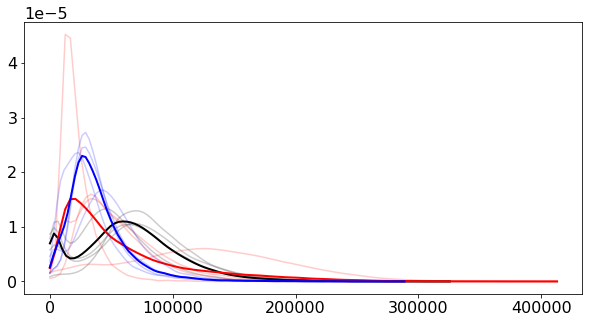

In [ ]:
colors=["k","red","blue"]
seasons=G55_AMNIS_df["season"].unique()
seasons.sort()

G55_AMNIS_df=G55_AMNIS_dfbk.copy()
G55_AMNIS_df=G55_AMNIS_df[G55_AMNIS_df["replicate"]!="Control"]

fig,ax=plt.subplots(figsize=(10,5)) 
for ic,season in enumerate(seasons):
    season_df=G55_AMNIS_df[G55_AMNIS_df["season"]==season]
    this_gs=season_df["Intensity_MC_Ch02"]
    maxg=this_gs.max()
    ming=this_gs.min()
    print(ming,maxg)
    xs=np.linspace(ming,maxg,100)

    den=gaussian_kde(this_gs)
    ys=den(xs)
    ax.plot(xs,ys,lw=2,c=colors[ic])
    reps=season_df["replicate"].unique()
    for rep in reps:
        t_df=season_df[season_df["replicate"]==rep]
        this_gs=t_df["Intensity_MC_Ch02"]
        den=gaussian_kde(this_gs)
        ys=den(xs)
        ax.plot(xs,ys,c=colors[ic],alpha=.2)
#plt.yscale("log")
#plt.xscale("log")
plt.show()

20000.2419354838 384609.350574715
[1 2 3]


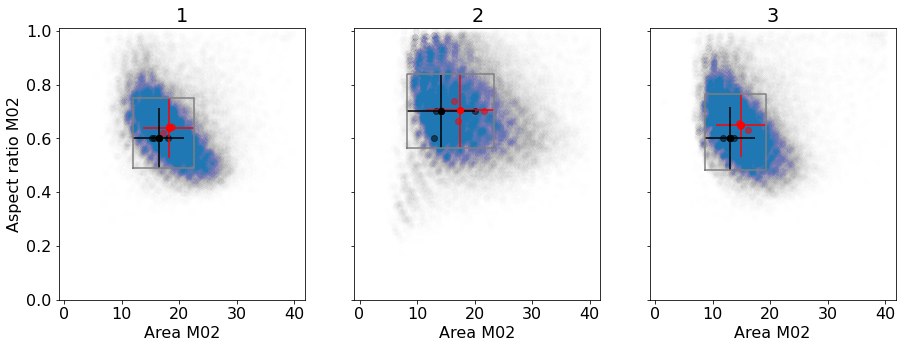

In [ ]:
seasons=G55_AMNIS_df["season"].unique()
seasons.sort()
nseasons=len(seasons)
rows=[1]
nrows=len(rows)

G55_AMNIS_df=G55_AMNIS_dfbk.copy()
G55_AMNIS_df=G55_AMNIS_df[G55_AMNIS_df["replicate"]!="Control"]

G55_AMNIS_df=G55_AMNIS_df[(G55_AMNIS_df["Intensity_MC_Ch02"]>20000)
                          &(G55_AMNIS_df["Area_M02"]<40) #40
                          ]


G55_AMNIS_df.round({"Area_M02":1,"Aspect Ratio_M02":2})

this_g=G55_AMNIS_df["Intensity_MC_Ch02"]
maxg=this_g.max()
ming=this_g.min()
print(ming,maxg)
print(seasons)
#ming=0
#maxg=500000

xs=np.linspace(ming,maxg,100)


G55_AMNIS_dflims={}
for season in seasons:
    G55_AMNIS_dflims[season]={}
    
fig,ax=plt.subplots(nrows,nseasons,figsize=(nseasons*5,nrows*5),sharey=True,sharex=True) 
for ic,season in enumerate(seasons):
    season_df=G55_AMNIS_df[(G55_AMNIS_df["season"]==season)
                &(G55_AMNIS_df["Area_M02"]<100) #40
                #&(G55_AMNIS_df["Aspect Ratio_M02"]>.35)
                #&(G55_AMNIS_df["Gradient RMS_M02_Ch02"]>40)
                ]
    ax[ic].set_title(season)

    
    xs=season_df["Area_M02"]
    ys=season_df["Aspect Ratio_M02"]
    ax[ic].scatter(xs,ys,alpha=.005)
    
    xs=[round(x,1) for x in list(season_df["Area_M02"])]
    xm=np.mean(xs)
    ys=[round(x,1) for x in list(season_df["Aspect Ratio_M02"])]
    ym=np.mean(ys)
    #print(x,y,end="\t")
    ax[ic].scatter(xm,ym,c='r',alpha=1)
    xsd=np.std(xs)
    ysd=np.std(ys)
    ax[ic].errorbar(xm, ym,xerr=xsd ,yerr=ysd,c='r',fmt='-o')
    
    xmo=stats.mode(xs).mode[0]
    ymo=stats.mode(ys).mode[0]
    #print(x,y)
    ax[ic].scatter(xmo,ymo,c='k',alpha=1)
    ax[ic].errorbar(xmo, ymo,xerr=xsd ,yerr=ysd,c='k',fmt='-o')
    reps=season_df["replicate"].unique()
    nsds=1
    max_x=max(xmo+nsds*xsd,xm+nsds*xsd)
    min_x=min(xmo-xsd,xm-xsd)
    max_y=max(ymo+nsds*ysd,ym+nsds*ysd)
    min_y=min(ymo-ysd,ym-ysd)
    G55_AMNIS_dflims[season]["Area"]=[min_x,max_x]
    G55_AMNIS_dflims[season]["Aspect"]=[min_y,max_y]
    ax[ic].plot([min_x,max_x,max_x,min_x,min_x],[min_y,min_y,max_y,max_y,min_y],c='gray')

    for rep in reps:
        t_df=season_df[season_df["replicate"]==rep]
        xs=[round(x,1) for x in list(t_df["Area_M02"])]
        x=np.mean(xs)
        ys=[round(x,1) for x in list(t_df["Aspect Ratio_M02"])]
        y=np.mean(ys)
        #print(x,y,end="\t")
        ax[ic].scatter(x,y,c='r',alpha=.5)
        x=stats.mode(xs).mode
        y=stats.mode(ys).mode
        #print(x,y)
        ax[ic].scatter(x,y,c='k',alpha=.5)
    ax[ic].set_xlabel("Area M02")
#ax[0].set_xlim([0,50])
ax[0].set_ylim([0,1.01])
ax[0].set_ylabel("Aspect ratio M02")

plt.show()



20000.2419354838 384609.350574715
[1 2 3]


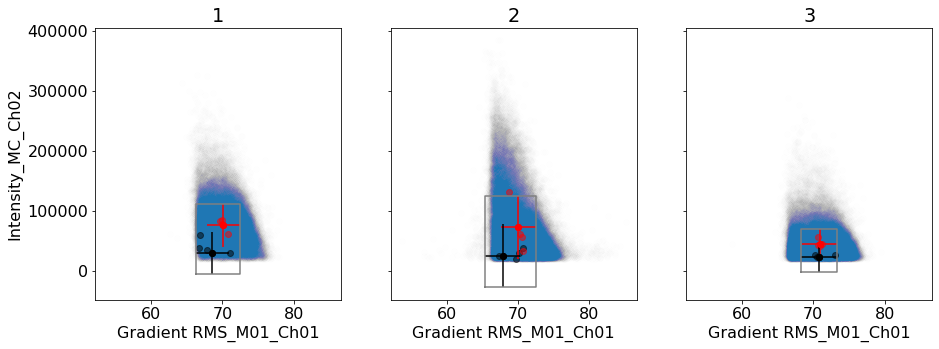

In [ ]:

seasons=G55_AMNIS_df["season"].unique()
seasons.sort()
nseasons=len(seasons)
rows=[1]
nrows=len(rows)

G55_AMNIS_df=G55_AMNIS_dfbk.copy()
G55_AMNIS_df=G55_AMNIS_df[G55_AMNIS_df["replicate"]!="Control"]
G55_AMNIS_df=G55_AMNIS_df[(G55_AMNIS_df["Intensity_MC_Ch02"]>20000)
                          &(G55_AMNIS_df["Area_M02"]<40) #40
                          ]


G55_AMNIS_df.round({"Area_M02":1,"Aspect Ratio_M02":2})

this_g=G55_AMNIS_df["Intensity_MC_Ch02"]
maxg=this_g.max()
ming=this_g.min()
print(ming,maxg)
print(seasons)
#ming=0
#maxg=500000

xs=np.linspace(ming,maxg,100)


    
fig,ax=plt.subplots(nrows,nseasons,figsize=(nseasons*5,nrows*5),sharey=True,sharex=True) 
for ic,season in enumerate(seasons):
    season_df=G55_AMNIS_df[(G55_AMNIS_df["season"]==season)
                &(G55_AMNIS_df["Area_M02"]<40) #40
                #&(G55_AMNIS_df["Aspect Ratio_M02"]>.35)
                #&(G55_AMNIS_df["Gradient RMS_M02_Ch02"]>40)
                ]
    ax[ic].set_title(season)

    
    xs=season_df["Gradient RMS_M01_Ch01"]
    ys=season_df["Intensity_MC_Ch02"]
    ax[ic].scatter(xs,ys,alpha=.005)
    
    xs=[round(x,1) for x in list(season_df["Gradient RMS_M01_Ch01"])]
    xm=np.mean(xs)
    ys=[round(x,1) for x in list(season_df["Intensity_MC_Ch02"])]
    ym=np.mean(ys)
    #print(x,y,end="\t")
    ax[ic].scatter(xm,ym,c='r',alpha=1)
    xsd=np.std(xs)
    ysd=np.std(ys)
    ax[ic].errorbar(xm, ym,xerr=xsd ,yerr=ysd,c='r',fmt='-o')
    
    xmo=stats.mode(xs).mode[0]
    ymo=stats.mode(ys).mode[0]
    #print(x,y)
    ax[ic].scatter(xmo,ymo,c='k',alpha=1)
    ax[ic].errorbar(xmo, ymo,xerr=xsd ,yerr=ysd,c='k',fmt='-o')
    reps=season_df["replicate"].unique()
    nsds=1
    max_x=max(xmo+nsds*xsd,xm+nsds*xsd)
    min_x=min(xmo-xsd,xm-xsd)
    max_y=max(ymo+nsds*ysd,ym+nsds*ysd)
    min_y=min(ymo-ysd,ym-ysd)

    ax[ic].plot([min_x,max_x,max_x,min_x,min_x],[min_y,min_y,max_y,max_y,min_y],c='gray')

    for rep in reps:
        t_df=season_df[season_df["replicate"]==rep]
        xs=[round(x,1) for x in list(t_df["Gradient RMS_M01_Ch01"])]
        x=np.mean(xs)
        ys=[round(x,1) for x in list(t_df["Intensity_MC_Ch02"])]
        y=np.mean(ys)
        #print(x,y,end="\t")
        ax[ic].scatter(x,y,c='r',alpha=.5)
        x=stats.mode(xs).mode
        y=stats.mode(ys).mode
        #print(x,y)
        ax[ic].scatter(x,y,c='k',alpha=.5)
    ax[ic].set_xlabel("Gradient RMS_M01_Ch01")
#ax[0].set_xlim([0,50])
#ax[0].set_ylim([0,1.01])
ax[0].set_ylabel("Intensity_MC_Ch02")

plt.show()


-1000 300000.0
12.001051717086732 22.56266192295225 0.4879834513107146 0.7505254533810939
9461 75572.04847431203 23321.3997118465 0.3085982209384434
	 3015 76551.38739456084 22508.512106765833 0.29403140652111964
	 1698 61026.56022901804 20515.13299513729 0.33616728385393047
	 2773 79574.7318160026 22097.82015329526 0.2776989585637705
	 1975 80962.47444365374 23444.371969471336 0.2895708429191794

8.291467990093583 23.444052699502848 0.5630697620649031 0.8404872471853653
17383 61880.40743807238 39228.30305418461 0.6339373749832342
	 5422 53697.525852873245 22125.556962902152 0.41204052908367395
	 5209 103707.6227603214 37122.85735641096 0.3579568827086661
	 3942 45799.24091199964 21506.963170395466 0.46959213170628183
	 2810 22692.356828512984 10031.245691172659 0.4420539376751022

8.666529146499826 19.281819944409264 0.48173736582790694 0.7665189978084566
12006 39262.99693979845 17929.55356886968 0.4566527001583929
	 3533 37635.202793803 15177.202789481942 0.40327144967532935
	 1977 4

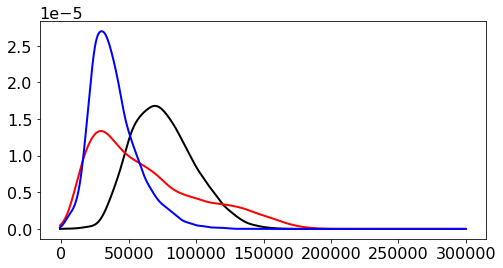

In [ ]:
seasons=G55_AMNIS_df["season"].unique()
seasons.sort()

G55_AMNIS_df=G55_AMNIS_dfbk.copy()
G55_AMNIS_df=G55_AMNIS_df[G55_AMNIS_df["replicate"]!="Control"]

G55_AMNIS_df.round({"Area_M02":1,"Aspect Ratio_M02":2})

lim_aspect=[.05, 1];
lim_area=[25, 35];


G55_AMNIS_df=G55_AMNIS_df[
                #(G55_AMNIS_df["Area_M02"]>lim_area[0])&(G55_AMNIS_df["Area_M02"]<lim_area[1])
                #&(G55_AMNIS_df["Aspect Ratio_M02"]>lim_aspect[0])&(G55_AMNIS_df["Aspect Ratio_M02"]<lim_aspect[1])
                (G55_AMNIS_df["Gradient RMS_M02_Ch02"]>40)
                &(G55_AMNIS_df["Area_M01"]>8) &( G55_AMNIS_df["Area_M01"]<25)
                &(G55_AMNIS_df["Aspect Ratio_M01"]>.35)&(G55_AMNIS_df["Aspect Ratio_M01"]<1)
                &(G55_AMNIS_df["Gradient RMS_M01_Ch01"]>65)&(G55_AMNIS_df["Gradient RMS_M01_Ch01"]<72)
                ]
# G55_AMNIS_df=G55_AMNIS_df[#(G55_AMNIS_df["Intensity_MC_Ch02"]>50000)
#                          (G55_AMNIS_df["Area_M02"]<80) #40
#                           #&(G55_AMNIS_df["Gradient RMS_M02_Ch02"]<43)
#                           &(G55_AMNIS_df["Gradient RMS_M02_Ch02"]>41)
#                           ]


this_g=G55_AMNIS_df["Intensity_MC_Ch02"]
maxg=this_g.max()
ming=this_g.min()
ming=-1000
maxg=3e5

print(ming,maxg)
xs=np.linspace(ming,maxg,1000)

fig,ax=plt.subplots(figsize=(8,4)) 
for ic,season in enumerate(seasons):
    season_df=G55_AMNIS_df[G55_AMNIS_df["season"]==season]
    #season_df=season_df[season_df["Intensity_MC_Ch02"]<maxg]
    [area_min,area_max]=G55_AMNIS_dflims[season]["Area"]
    [aspect_min,aspect_max]=G55_AMNIS_dflims[season]["Aspect"]
    print(area_min,area_max,aspect_min,aspect_max)
    season_df=season_df[(season_df["Area_M02"]>area_min)&(season_df["Area_M02"]<area_max)
               &(season_df["Aspect Ratio_M02"]>aspect_min)&(season_df["Aspect Ratio_M02"]<aspect_max)
               ]

    this_gs=season_df["Intensity_MC_Ch02"]
    this_mean=np.mean(this_gs)
    this_sd=np.std(this_gs)
    this_cv=this_sd/this_mean
    print(this_gs.size,this_mean,this_sd,this_cv)
    this_gs2=[int(x) for x in this_gs]
    den=gaussian_kde(this_gs2)
    ys=den(xs)
    yma=max(ys)
    
    ax.plot(xs,ys,lw=2,c=colors[ic])
    xmode=stats.mode(this_gs2).mode
    reps=season_df["replicate"].unique()
    
    for rep in reps:
        t_df=season_df[season_df["replicate"]==rep]
        this_gs=t_df["Intensity_MC_Ch02"]
        this_mean=np.mean(this_gs)
        this_sd=np.std(this_gs)
        this_cv=this_sd/this_mean
        print("\t",this_gs.size,this_mean,this_sd,this_cv)
        #ax.plot(xs,ys,c='k',alpha=.2)
    
    print()

#plt.yscale("log")
#plt.xscale("log")
plt.show()



## Synergy

In [ ]:

#Synergy_dataPath="./data/"
synergy_files=['pBGTx4-G54Ux4-G55Ux4_AMP+SB-AMP_1-LB.txt', 'pBGTx4-G54Ux4-G55Ux4_AMP+SB-AMP_2-AMP.txt', 'pBGTx4-G54Ux4-G55Ux4_AMP+SB-AMP_3-LB.txt']
synergy_G54=["D5","C6","D7","C8","G5","F6","G7","F8"]
synergy_G54C=["B5","E5"]

synergy_G55=["D9","C10","D11","C12","G9","F10","G11","F12"]
synergy_G55C=["B9","E9"]

synergy_P=["G1","G2","G3","G4"]
synergy_PS=["D1","C2","D3","C4","F1","F2","F3","F4"]
synergy_PC=["B1","E1"]

synergy_used_wells=synergy_G54+synergy_G54C+synergy_G55+synergy_G55C+synergy_P+synergy_PS+synergy_PC


synergy_namesSB=["1-LB","2-AMP+SB","3-LB"]
synergy_names=["1-LB","2-AMP","3-LB"]
synergy_namesS=["1-LB","2-AMP+SB","3-LB"]
synergy_namesL=["1-LB","2-LB","3-LB"]


In [ ]:
synergy_dflist=[]
for i,this_file in enumerate(synergy_files):
    this_file=synergy_raw_data_path+this_file
    df=pd.read_csv(this_file,sep='\t',skiprows=45,nrows=37)
    times=list(df["Time"])
    this_size=len(times)
    dname=synergy_names[i]
    d_list=[dname]*this_size
    #print(df.tail())            
    df_temp=pd.DataFrame({"Time":times,"day":d_list})
        
    df2=pd.merge(df,df_temp, on=["Time"])
    synergy_dflist.append(df2)
synergy_df_OD=pd.concat(synergy_dflist)
synergy_df_OD.head()
    
    

,Time,T° OD:630,A1,A2,A3,A4,A5,A6,A7,A8,...,H4,H5,H6,H7,H8,H9,H10,H11,H12,day
0,0:00:32,37.0,0.104,0.089,0.095,0.089,0.089,0.087,0.090,0.088,...,0.087,0.088,0.088,0.087,0.087,0.099,0.087,0.099,0.087,1-LB
1,0:20:32,37.0,0.103,0.088,0.094,0.088,0.088,0.087,0.089,0.088,...,0.094,0.088,0.087,0.086,0.087,0.097,0.087,0.093,0.087,1-LB
2,0:40:32,37.0,0.102,0.088,0.094,0.090,0.088,0.087,0.089,0.088,...,0.094,0.088,0.087,0.086,0.087,0.096,0.086,0.091,0.089,1-LB
3,1:00:32,37.0,0.102,0.088,0.095,0.091,0.090,0.090,0.090,0.091,...,0.094,0.088,0.087,0.086,0.087,0.095,0.087,0.091,0.090,1-LB
4,1:20:32,37.0,0.102,0.089,0.095,0.091,0.090,0.090,0.090,0.091,...,0.094,0.088,0.087,0.086,0.087,0.095,0.088,0.091,0.091,1-LB


In [ ]:
dflist=[]
for i,this_file in enumerate(synergy_files):
    this_file=synergy_raw_data_path+this_file
    df=pd.read_csv(this_file,sep='\t',skiprows=86,nrows=37)
    times=list(df["Time"])
    this_size=len(times)
    dname=synergy_names[i]
    d_list=[dname]*this_size
    df_temp=pd.DataFrame({"Time":times,"day":d_list})
    df2=pd.merge(df,df_temp, on=["Time"])
    dflist.append(df2)
synergy_df_GFP=pd.concat(dflist)
synergy_df_GFP.head()
    
    

,Time,"T° GFP:479,520",A1,A2,A3,A4,A5,A6,A7,A8,...,H4,H5,H6,H7,H8,H9,H10,H11,H12,day
0,0:01:23,37.0,16971,17041,16883,16940,16667,16829,16727,16649,...,16716,16682,17006,16843,17030,16687,16642,16863,16842,1-LB
1,0:21:23,37.0,16509,16304,16375,16171,16123,16210,15799,15862,...,16052,16076,16017,16243,15812,15748,16040,16138,16271,1-LB
2,0:41:23,37.0,16185,16357,15940,15959,16025,15912,16064,16006,...,16149,16185,16181,15833,15868,15910,15842,15560,15831,1-LB
3,1:01:23,37.0,16333,16258,16153,16173,16273,15956,16154,15771,...,15846,16207,16128,15943,15700,15773,15807,15797,16016,1-LB
4,1:21:23,37.0,16447,16376,16037,15951,16060,15891,16029,15667,...,15809,16117,15960,15945,15722,16053,15723,15792,16127,1-LB


In [ ]:
dflist=[]
for i,this_file in enumerate(synergy_files):
    this_file=synergy_raw_data_path+this_file
    df=pd.read_csv(this_file,sep='\t',skiprows=127,nrows=37)
    times=list(df["Time"])
    this_size=len(times)
    dname=synergy_names[i]
    d_list=[dname]*this_size
    df_temp=pd.DataFrame({"Time":times,"day":d_list})
    df2=pd.merge(df,df_temp, on=["Time"])
    dflist.append(df2)
synergy_df_GFPOD=pd.concat(dflist)
synergy_df_GFPOD.tail()
    
    

,Time,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,H4,H5,H6,H7,H8,H9,H10,H11,H12,day
32,10:41:23,152267,184983,194185,157610,156153,139664,178209,123117,182930,...,190057,187474,172977,179835,168146,160186,140644,183243,140613,3-LB
33,11:01:23,154778,186315,194116,159817,153289,140811,181826,121738,185215,...,190806,188992,173770,183145,167818,157186,141447,183121,143828,3-LB
34,11:21:23,153463,187089,191942,158412,155955,141087,179422,122176,180363,...,191065,188089,171674,181963,170104,159843,141493,183417,141640,3-LB
35,11:41:23,153834,188293,193098,160366,156585,139656,179410,121985,180793,...,191019,191304,172293,177874,168741,160678,142608,185079,140550,3-LB
36,12:01:23,154044,188113,193087,160444,154725,142336,180557,121485,182877,...,190956,191223,170921,181330,168717,160885,144257,181759,143044,3-LB


## GFP/OD dbg

In [ ]:
synergy_df_GFPODdbg=synergy_df_GFPOD.copy()
baseline_od_list=[]
baseline_gfp_list=[]
for key in synergy_df_GFPODdbg.keys():
    if((key=="day") or (key=="Time") or (key in synergy_used_wells)):
        continue
    #print(list(synergy_df_OD[key]))
    this_well_od=list(synergy_df_OD[key])
    this_well_gfp=list(synergy_df_GFP[key])
    baseline_od_list=baseline_od_list+this_well_od
    baseline_gfp_list=baseline_gfp_list+this_well_gfp
    
baseline_od=np.mean(baseline_od_list)
baseline_od=np.min(baseline_od_list)
baseline_od=np.min(baseline_od_list)-.007
baseline_od=.08
print("Baseline OD", baseline_od)
baseline_gfp=np.mean(baseline_gfp_list)
baseline_gfp=np.min(baseline_gfp_list)
print("Baseline GFP", baseline_gfp)

for key in synergy_used_wells:
    
    this_well_od_list=[x-baseline_od if x>=baseline_od else np.nan for x in list(synergy_df_OD[key])]
    this_well_gfp_list=[x-baseline_gfp if x>=baseline_gfp else 0 for x in list(synergy_df_GFP[key])]
    this_well_GFPOD_list=[gfp/od for gfp,od in zip(this_well_gfp_list,this_well_od_list)]
    #print(this_well_GFPOD_list)
    synergy_df_GFPODdbg[key]=this_well_GFPOD_list
synergy_df_GFPODdbg.head()

Baseline OD 0.08
Baseline GFP 1869


,Time,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,H4,H5,H6,H7,H8,H9,H10,H11,H12,day
0,0:01:23,162402,192120,177903,190337,188115,193437,186062,188978,135213,...,192138,188924,194132,194044,194629,167877,190630,170333,193586,1-LB
1,0:21:23,160126,184853,173464,182723,182800,187182,177717,180661,136133,...,171130,181855,183892,187780,181123,163023,184580,174276,187238,1-LB
2,0:41:23,158832,185664,169035,177717,181896,181851,181105,181268,132414,...,172348,183296,185775,183040,181972,166249,183145,170989,178277,1-LB
3,1:01:23,160127,184122,170931,177921,181416,177289,179689,173881,131156,...,168934,183753,185166,184525,179840,165857,182318,173784,177364,1-LB
4,1:21:23,161403,183793,168988,174901,177852,175980,177705,171787,130356,...,168539,182525,183238,184335,180092,169157,179282,173348,177610,1-LB


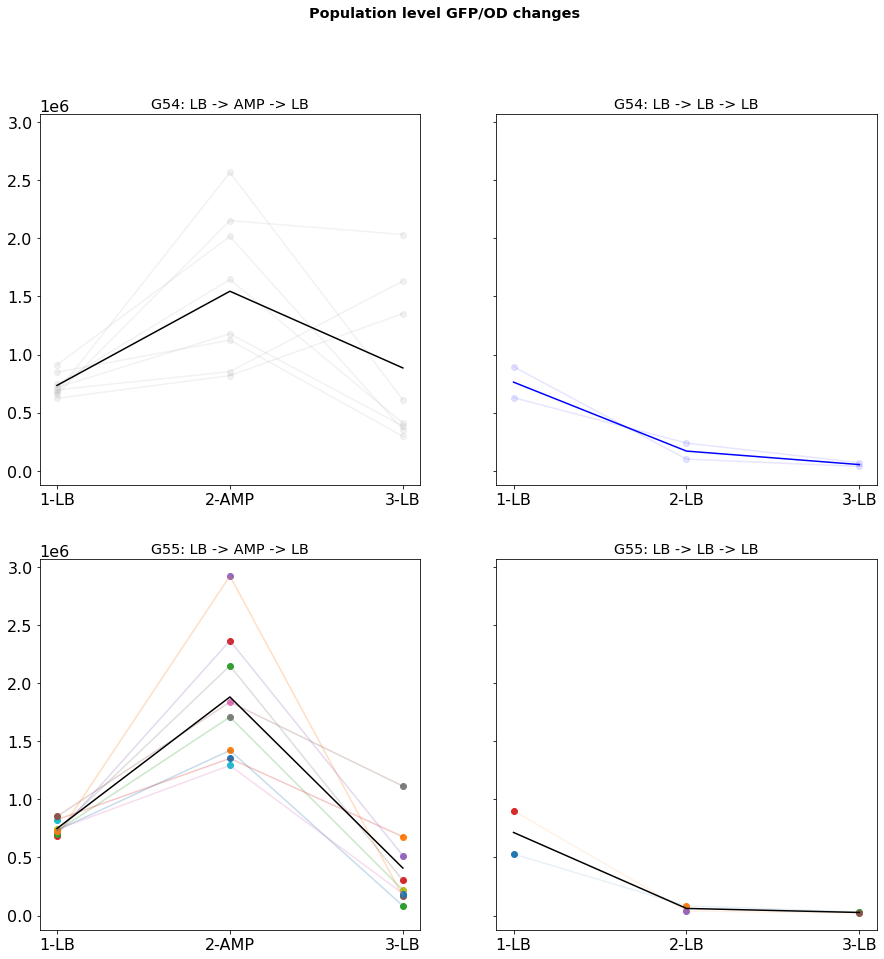

In [ ]:

df_plt=synergy_df_GFPOD.copy()
df_plt=synergy_df_GFPODdbg.copy()
fig, ax = plt.subplots(2,2, figsize=(15, 15),sharey=True)
#fig.subplots_adjust(left=0.2) # or whatever
plt.rcParams.update({'font.size': 12})


dfos=[]
for rep in synergy_G54:
    fods=[]
    for d,day in enumerate(synergy_names):
        subdf=df_plt[df_plt["day"]==day]
        ods=list(subdf[rep])
        #maxod=max(ods)
        fod=ods[-1]
        fods.append(fod)
        ax[0,0].scatter(x=d,y=fod,c='gray',alpha=.1)
    dfos.append(fods)
    ax[0,0].plot([0,1,2],fods,c='gray',alpha=.1)
y0=np.mean([x[0] for x in dfos])
y1=np.mean([x[1] for x in dfos])
y2=np.mean([x[2] for x in dfos])
ax[0,0].plot([0,1,2],[y0,y1,y2],c='k')
ax[0,0].set_xticks([0,1,2])
ax[0,0].set_title("G54: LB -> AMP -> LB")
ax[0,0].set_xticklabels(synergy_names)

dfos=[]
for rep in synergy_G54C:
    fods=[]
    for d,day in enumerate(synergy_names):
        subdf=df_plt[df_plt["day"]==day]
        ods=list(subdf[rep])
        #maxod=max(ods)
        fod=ods[-1]
        fods.append(fod)
        ax[0,1].scatter(x=d,y=fod,c='blue',alpha=.1)
    dfos.append(fods)
    ax[0,1].plot([0,1,2],fods,c='blue',alpha=.1)
y0=np.mean([x[0] for x in dfos])
y1=np.mean([x[1] for x in dfos])
y2=np.mean([x[2] for x in dfos])
ax[0,1].plot([0,1,2],[y0,y1,y2],c='blue')

ax[0,1].set_xticks([0,1,2])
ax[0,1].set_title("G54: LB -> LB -> LB")
ax[0,1].set_xticklabels(synergy_namesL)

###############################################
dfos=[]
for rep in synergy_G55:
    fods=[]
    for d,day in enumerate(synergy_names):
        subdf=df_plt[df_plt["day"]==day]
        ods=list(subdf[rep])
        #maxod=max(ods)
        fod=ods[-1]
        fods.append(fod)
        ax[1,0].scatter(x=d,y=fod)
    dfos.append(fods)
    ax[1,0].plot([0,1,2],fods,alpha=.25)
y0=np.mean([x[0] for x in dfos])
y1=np.mean([x[1] for x in dfos])
y2=np.mean([x[2] for x in dfos])
ax[1,0].plot([0,1,2],[y0,y1,y2],c='k')
ax[1,0].set_xticks([0,1,2])
ax[1,0].set_title("G55: LB -> AMP -> LB")
ax[1,0].set_xticklabels(synergy_names)

dfos=[]
for rep in synergy_G55C:
    fods=[]
    for d,day in enumerate(synergy_names):
        subdf=df_plt[df_plt["day"]==day]
        ods=list(subdf[rep])
        #maxod=max(ods)
        fod=ods[-1]
        fods.append(fod)
        ax[1,1].scatter(x=d,y=fod)
    dfos.append(fods)
    ax[1,1].plot([0,1,2],fods,alpha=.1)
y0=np.mean([x[0] for x in dfos])
y1=np.mean([x[1] for x in dfos])
y2=np.mean([x[2] for x in dfos])
ax[1,1].plot([0,1,2],[y0,y1,y2],c='k')
ax[1,1].set_xticks([0,1,2])
ax[1,1].set_title("G55: LB -> LB -> LB")
ax[1,1].set_xticklabels(synergy_namesL)


plt.suptitle("Population level GFP/OD changes",fontweight=850)
#plt.savefig("./figs/PopLevelGFPOD_G54G55_synergy.pdf")
plt.show()


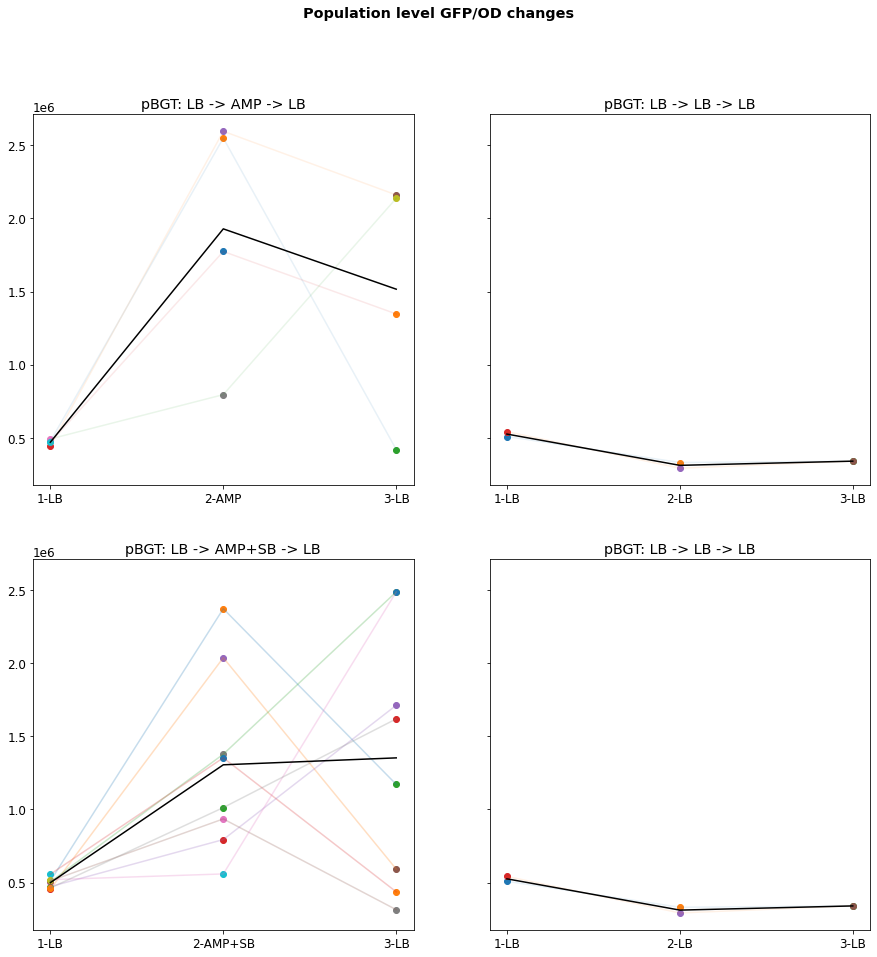

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(15, 15),sharey=True)
#fig.subplots_adjust(left=0.2) # or whatever
plt.rcParams.update({'font.size': 12})


dfos=[]
for rep in synergy_P:
    fods=[]
    for d,day in enumerate(synergy_names):
        subdf=df_plt[df_plt["day"]==day]
        ods=list(subdf[rep])
        #maxod=max(ods)
        fod=ods[-1]
        fods.append(fod)
        ax[0,0].scatter(x=d,y=fod)
    dfos.append(fods)
    ax[0,0].plot([0,1,2],fods,alpha=.1)
y0=np.mean([x[0] for x in dfos])
y1=np.mean([x[1] for x in dfos])
y2=np.mean([x[2] for x in dfos])
ax[0,0].plot([0,1,2],[y0,y1,y2],c='k')
ax[0,0].set_xticks([0,1,2])
ax[0,0].set_title("pBGT: LB -> AMP -> LB")
ax[0,0].set_xticklabels(synergy_names)

dfos=[]
for rep in synergy_PC:
    fods=[]
    for d,day in enumerate(synergy_names):
        subdf=df_plt[df_plt["day"]==day]
        ods=list(subdf[rep])
        #maxod=max(ods)
        fod=ods[-1]
        fods.append(fod)
        ax[0,1].scatter(x=d,y=fod)
    dfos.append(fods)
    ax[0,1].plot([0,1,2],fods,alpha=.1)
y0=np.mean([x[0] for x in dfos])
y1=np.mean([x[1] for x in dfos])
y2=np.mean([x[2] for x in dfos])
ax[0,1].plot([0,1,2],[y0,y1,y2],c='k')
ax[0,1].set_xticks([0,1,2])
ax[0,1].set_title("pBGT: LB -> LB -> LB")
ax[0,1].set_xticklabels(synergy_namesL)

###############################################
dfos=[]
for rep in synergy_PS:
    fods=[]
    for d,day in enumerate(synergy_names):
        subdf=df_plt[df_plt["day"]==day]
        ods=list(subdf[rep])
        #maxod=max(ods)
        fod=ods[-1]
        fods.append(fod)
        ax[1,0].scatter(x=d,y=fod)
    dfos.append(fods)
    ax[1,0].plot([0,1,2],fods,alpha=.25)
y0=np.mean([x[0] for x in dfos])
y1=np.mean([x[1] for x in dfos])
y2=np.mean([x[2] for x in dfos])
ax[1,0].plot([0,1,2],[y0,y1,y2],c='k')
ax[1,0].set_xticks([0,1,2])
ax[1,0].set_title("pBGT: LB -> AMP+SB -> LB")
ax[1,0].set_xticklabels(synergy_namesS)

dfos=[]
for rep in synergy_PC:
    fods=[]
    for d,day in enumerate(synergy_names):
        subdf=df_plt[df_plt["day"]==day]
        ods=list(subdf[rep])
        #maxod=max(ods)
        fod=ods[-1]
        fods.append(fod)
        ax[1,1].scatter(x=d,y=fod)
    dfos.append(fods)
    ax[1,1].plot([0,1,2],fods,alpha=.1)
y0=np.mean([x[0] for x in dfos])
y1=np.mean([x[1] for x in dfos])
y2=np.mean([x[2] for x in dfos])
ax[1,1].plot([0,1,2],[y0,y1,y2],c='k')
ax[1,1].set_xticks([0,1,2])
ax[1,1].set_title("pBGT: LB -> LB -> LB")
ax[1,1].set_xticklabels(synergy_namesL)

plt.suptitle("Population level GFP/OD changes",fontweight=850)
#plt.savefig("./figs/PopLevelGFPOD_pBGTInhibitor_synergy.pdf")
plt.show()


### Joint plot


Saving fig as: 
 /content/drive/MyDrive/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig_G54U_G55U.pdf


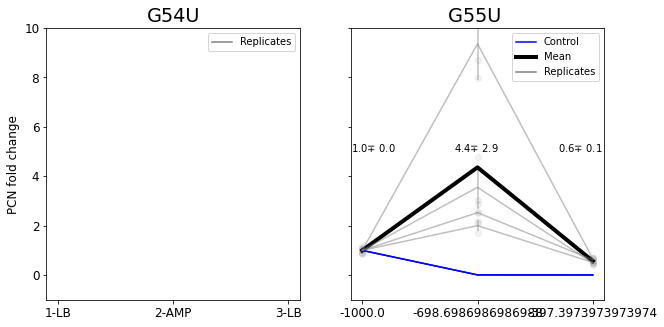

In [ ]:

fig,ax=plt.subplots(1,2,figsize=(10,5),sharey=True)
fig.set_facecolor('white')
plt.rcParams.update({'font.size': 16})

plt_df=G54_df_all


################################# G55

col_mean=[]
col_std=[]

for row in range(0,len(G55_control_days_dxs)):
    row_mean_d=[]
    row_mean_t=[]
    row_mean_cn=[]
    for ci,col in enumerate(G55_control_repsT):
        well_d=G55_control_days_dxs[row]+str(col)
        well_t=G55_control_days_tem[row]+str(col)
        ct_d=list(G55_df_all[G55_df_all["Well"]==well_d]["Cq"])[0]
        ct_t=list(G55_df_all[G55_df_all["Well"]==well_t]["Cq"])[0]
        cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
        
 
        if(np.isnan(cn_eff)):
            continue
        row_mean_d.append(ct_d)
        row_mean_t.append(ct_t)
        row_mean_cn.append(cn_eff)
        
    mean_d=np.mean(row_mean_d)
    mean_t=np.mean(row_mean_t)
    mean_cn=np.mean(row_mean_cn)
    col_mean.append(mean_cn)
    std_cn=np.std(row_mean_cn)
    col_std.append(std_cn)

col_std=[x/col_mean[0] for x in col_std]
col_mean=[x/col_mean[0] for x in col_mean]

ax[1].plot([1,2,3],col_mean,c='blue',label="Control")   
ax[1].errorbar([1,2,3],col_mean,yerr=col_std,c='blue')   
# # for x in range(1,4):
# #     m=round(col_mean[x-1],1)
# #     ax[1].text(x-.1,m+25,'%s'%(m))

# normv=1

all_means=[]
for ri in range(0,len(G55_repsB_dxs)):
    bio_mean_cn=[]
    bio_std_cn=[]
    for di,day in enumerate(G55_days):
        tech_mean_d=[]
        tech_mean_t=[]
        tech_mean_cn=[]
        for ci,col in enumerate(day):
            well_d=G55_repsB_dxs[ri]+col
            well_t=G55_repsB_tem[ri]+col
            ct_d=list(G55_df_all[G55_df_all["Well"]==well_d]["Cq"])[0]
            ct_t=list(G55_df_all[G55_df_all["Well"]==well_t]["Cq"])[0]
            cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
            normv=col_mean[0]
            cn_eff=cn_eff/normv
            
            if(np.isnan(cn_eff)):
                #print("xxx",well_d, well_t)
                continue
            if(well_d in G55_ex_wells or well_t in G55_ex_wells):
                #print("xxxxx",well_d, well_t)
                continue
            tech_mean_d.append(ct_d)
            tech_mean_t.append(ct_t)
            tech_mean_cn.append(cn_eff)
        
        mean_d=np.mean(tech_mean_d)
        mean_t=np.mean(tech_mean_t)
    
        mean_cn=np.mean(tech_mean_cn)
        std_cn=np.std(tech_mean_cn)
        bio_mean_cn.append(mean_cn)
        bio_std_cn.append(std_cn)

        tech_mean_cnN=[x/bio_mean_cn[0] for x in tech_mean_cn]
        ax[1].scatter([di+1]*len(tech_mean_cnN),tech_mean_cnN,c="gray",alpha=.1)       
        

    bio_std_cn=[x/bio_mean_cn[0] for x in bio_std_cn]
    bio_mean_cn=[x/bio_mean_cn[0] for x in bio_mean_cn]
    all_means.append(bio_mean_cn)

    ax[1].errorbar([1,2,3],bio_mean_cn,yerr=bio_std_cn,c="gray",alpha=.5)#,marker=(5, 2),label="Rep-%s"%ri)
y1=[x[0] for x in all_means]    
y2=[x[1] for x in all_means]    
y3=[x[2] for x in all_means]
ys=[y1,y2,y3]
means=[np.mean(y) for y in ys]
stds=[np.std(y) for y in ys]
ax[1].plot([1,2,3],means,c='k',lw=4,label="Mean")






ax[0].plot([1,2,3],[-100,-10,-10],c='gray',label="Replicates")
ax[1].plot([1,2,3],[-100,-10,-10],c='gray',label="Replicates")
ax[0].set_ylim([-1,10])

ax[1].set_xticks([1,2,3])
ax[1].set_xticklabels(xs)
ax[1].set_title("G55U ")


xs=["1-LB","2-AMP","3-LB"]
ax[0].set_xticks([1,2,3])
ax[0].set_xticklabels(xs)
ax[0].set_ylabel("PCN fold change")
ax[0].set_title("G54U")
for x in range(1,4):
    m=round(means[x-1],1)
    s=round(stds[x-1],1)
    ax[1].text(x-(.1*x),5,r'%s$\mp$ %s'%(m,s),fontsize=10)

ax[0].legend(fontsize=10)
ax[1].legend(fontsize=10)

#ax[1].set_yscale("log")

print("Saving fig as: \n",out_fig_name)
#plt.savefig(out_fig_name,bbox_inches = 'tight',pad_inches = 0.1)

plt.show()



In [ ]:
def plot_synergy_axs(ax,xax,yax,synergy_reps,synergy_repsC,df_plt,synergy_names):
    dfos=[]
    for rep in synergy_reps:
        fods=[]
        for d,day in enumerate(synergy_names):
            subdf=df_plt[df_plt["day"]==day]
            ods=list(subdf[rep])
            #maxod=max(ods)
            fod=ods[-1]
            fods.append(fod)
            ax[xax,yax].scatter(x=d,y=fod,c='gray',alpha=.1)
        dfos.append(fods)
        ax[xax,yax].plot([0,1,2],fods,c='gray',alpha=.1)
    y0=np.mean([x[0] for x in dfos])
    y1=np.mean([x[1] for x in dfos])
    y2=np.mean([x[2] for x in dfos])
    ax[xax,yax].plot([0,1,2],[y0,y1,y2],c='k')
    

    dfos=[]
    for rep in synergy_repsC:
        fods=[]
        for d,day in enumerate(synergy_names):
            subdf=df_plt[df_plt["day"]==day]
            ods=list(subdf[rep])
            #maxod=max(ods)
            fod=ods[-1]
            fods.append(fod)
            ax[0,1].scatter(x=d,y=fod,c='blue',alpha=.1)
        dfos.append(fods)
        ax[xax,yax].plot([0,1,2],fods,c='blue',alpha=.1)
    y0=np.mean([x[0] for x in dfos])
    y1=np.mean([x[1] for x in dfos])
    y2=np.mean([x[2] for x in dfos])
    ax[xax,yax].plot([0,1,2],[y0,y1,y2],c='blue')

    ax[xax,yax].set_xticks([0,1,2])
    #ax[xax,yax].set_title("G54: LB -> AMP -> LB")
    ax[xax,yax].set_xticklabels(synergy_names)
    ax[xax,yax].set_ylabel("GFP/OD")
 
    return ax

def plot_qPCR_axs(ax,xax,yax,strain_control_days_dxs,strain_control_days_tem,strain_control_repsT,strain_repsB_dxs,strain_repsB_tem,strain_ex_wells,strain_days,plt_df):

    col_mean=[]
    col_std=[]
    for row in range(0,len(strain_control_days_dxs)):
        row_mean_d=[]
        row_mean_t=[]
        row_mean_cn=[]
        for ci,col in enumerate(strain_control_repsT):
            well_d=strain_control_days_dxs[row]+str(col)
            well_t=strain_control_days_tem[row]+str(col)
            ct_d=list(plt_df[plt_df["Well"]==well_d]["Cq"])[0]
            ct_t=list(plt_df[plt_df["Well"]==well_t]["Cq"])[0]
            cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
            if(np.isnan(cn_eff)):
                continue
            row_mean_d.append(ct_d)
            row_mean_t.append(ct_t)
            row_mean_cn.append(cn_eff)
            
        mean_d=np.mean(row_mean_d)
        mean_t=np.mean(row_mean_t)
        mean_cn=np.mean(row_mean_cn)
        col_mean.append(mean_cn)
        std_cn=np.std(row_mean_cn)
        col_std.append(std_cn)

    col_std=[x/col_mean[0] for x in col_std]
    col_mean=[x/col_mean[0] for x in col_mean]

    ax[xax,yax].plot([1,2,3],col_mean,c='blue',label="Control")   
    ax[xax,yax].errorbar([1,2,3],col_mean,yerr=col_std,c='blue')   
    # for x in range(1,4):
    #     m=round(col_mean[x-1],1)
    #     ax[1].text(x-.1,m+25,'%s'%(m))

    normv=1

    all_means=[]
    for ri in range(0,len(strain_repsB_dxs)):
        bio_mean_cn=[]
        bio_std_cn=[]
        for di,day in enumerate(strain_days):
            tech_mean_d=[]
            tech_mean_t=[]
            tech_mean_cn=[]
            for ci,col in enumerate(day):
                well_d=strain_repsB_dxs[ri]+col
                well_t=strain_repsB_tem[ri]+col
                ct_d=list(plt_df[plt_df["Well"]==well_d]["Cq"])[0]
                ct_t=list(plt_df[plt_df["Well"]==well_t]["Cq"])[0]
                cn_eff=((1+eff_dxs)**ct_d)/((1+eff_tem)**ct_t)
                            
                if(np.isnan(cn_eff)):
                    #print("xxx",well_d, well_t)
                    continue
                if(well_d in strain_ex_wells or well_t in strain_ex_wells):
                    #print("xxxxx",well_d, well_t)
                    continue
                tech_mean_d.append(ct_d)
                tech_mean_t.append(ct_t)
                tech_mean_cn.append(cn_eff)
                #ax[xax,yax].scatter(di+1,cn_eff,c="gray",alpha=.1)
            mean_d=np.mean(tech_mean_d)
            mean_t=np.mean(tech_mean_t)
        
            mean_cn=np.mean(tech_mean_cn)
            std_cn=np.std(tech_mean_cn)
            bio_mean_cn.append(mean_cn)
            bio_std_cn.append(std_cn)
    
            tech_mean_cnN=[x/bio_mean_cn[0] for x in tech_mean_cn]
            ax[xax,yax].scatter([di+1]*len(tech_mean_cnN),tech_mean_cnN,c="gray",alpha=.1)       
            
        bio_std_cn=[x/bio_mean_cn[0] for x in bio_std_cn]
        bio_mean_cn=[x/bio_mean_cn[0] for x in bio_mean_cn]
        all_means.append(bio_mean_cn)

        ax[xax,yax].errorbar([1,2,3],bio_mean_cn,yerr=bio_std_cn,c="gray",alpha=.5)#,marker=(5, 2),label="Rep-%s"%ri)
    y1=[x[0] for x in all_means]    
    y2=[x[1] for x in all_means]    
    y3=[x[2] for x in all_means]
    ys=[y1,y2,y3]
    means=[np.mean(y) for y in ys]
    stds=[np.std(y) for y in ys]
    ax[xax,yax].plot([1,2,3],means,c='k',lw=4,label="Mean")

   
    ax[xax,yax].set_ylabel("PCN fold change")
    ax[xax,yax].plot([1,2,3],[-100,-10,-10],c='gray',label="Replicates")
    ax[xax,yax].set_ylim([-1,10])

    xs=["1-LB","2-AMP","3-LB"]
    ax[xax,yax].set_xticks([1,2,3])
    ax[xax,yax].set_xticklabels(xs)

    for x in range(1,4):
        m=round(means[x-1],1)
        s=round(stds[x-1],1)
        ax[xax,yax].text(x-(.1*x),5,r'%s$\mp$ %s'%(m,s),fontsize=10)

    ax[xax,yax].legend(fontsize=10)
    #ax[0].set_title("G55U")
    return ax



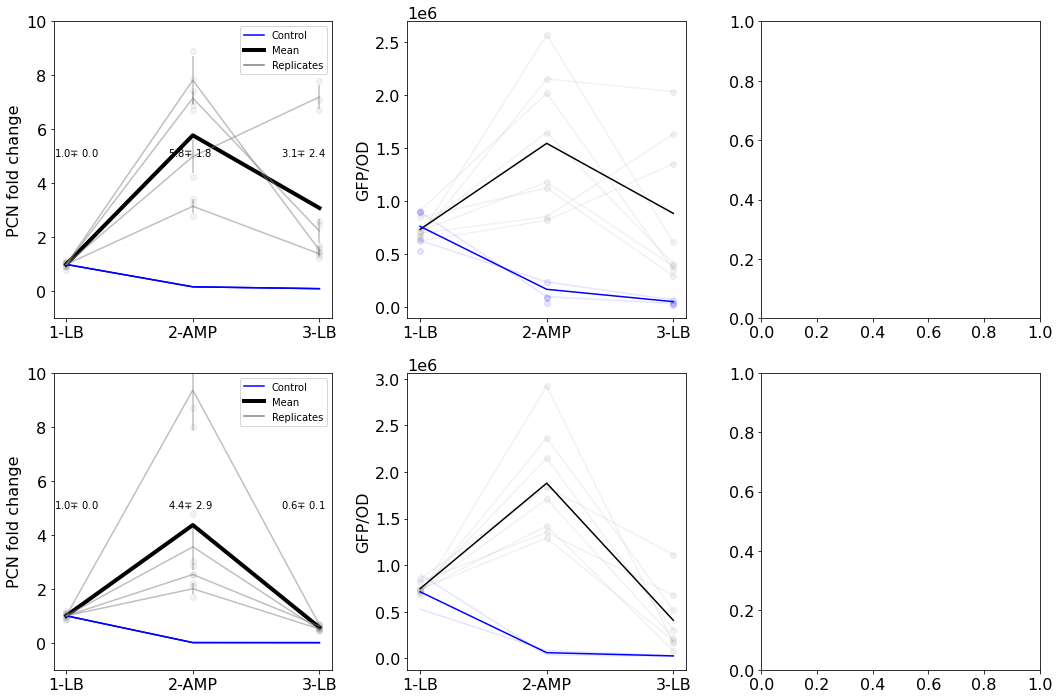

In [ ]:

fig, ax = plt.subplots(2,3, figsize=(15, 10),sharey=False)
#fig.subplots_adjust(left=0.2) # or whatever
plt.rcParams.update({'font.size': 16})


ax=plot_synergy_axs(ax,0,1,synergy_G54,synergy_G54C,synergy_df_GFPODdbg,synergy_names)
ax=plot_synergy_axs(ax,1,1,synergy_G55,synergy_G55C,synergy_df_GFPODdbg,synergy_names)

ax=plot_qPCR_axs(ax,0,0,G54_control_days_dxs,G54_control_days_tem,G54_control_repsT,G54_repsB_dxs,G54_repsB_tem,G54_ex_wells,G55_days,G54_df_all)
ax=plot_qPCR_axs(ax,1,0,G55_control_days_dxs,G55_control_days_tem,G55_control_repsT,G55_repsB_dxs,G55_repsB_tem,G55_ex_wells,G55_days,G55_df_all)

plt.tight_layout()

plt.show()